# Model comparison: Kalman TVP vs OLS / Ridge / Lasso / Elastic Net / Rolling OLS / CatBoost / PatchTST

Этот ноутбук повторяет логику rolling / expanding backtest из исходного `kalman_tvp_full_notebook`,
но добавляет сравнение с моделями:

- `kalman_tvp`
- `ols`
- `ridge`
- `lasso`
- `elastic_net`
- `rolling_ols`
- `catboost_lags_regimes`
- `patchtst_global`

Что делает ноутбук:

1. Готовит панель так же, как в исходном ноутбуке.
2. Прогоняет quarterly out-of-sample backtest для всех моделей.
3. Для регуляризованных и новых benchmark-моделей подбирает гиперпараметры на последних `validation_periods` кварталах.
4. Для `rolling_ols` подбирает длину окна по `rolling_window_grid`.
5. Для `catboost_lags_regimes` использует тот же набор признаков + лаги по этим признакам.
6. Для `patchtst_global` обучает глобальную sequence-модель класса PatchTST сразу на всех акциях.
7. В конце строит `shap.summary_plot()` / SHAP-compatible attribution plot для **каждой** модели.

Важно по SHAP / attribution:

- для `OLS / Ridge / Lasso / Elastic Net` SHAP считается по каждому out-of-sample кварталу и затем объединяется;
- для `Rolling OLS` и `Kalman TVP` SHAP также считается **по каждому кварталу со своими коэффициентами**, после чего объединяется в один `summary_plot` по модели;
- для `catboost_lags_regimes` используется нативный `CatBoost` Tree SHAP;
- для `patchtst_global` используется gradient-based attribution в SHAP-compatible формате, чтобы сохранить тот же интерфейс сравнения.

Это даёт глобальную картину важности признаков по всему бэктесту, а не только на последней дате.

In [1]:

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [15]:
from __future__ import annotations

from dataclasses import dataclass, field
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Sequence, Tuple

import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from sklearn.linear_model import ElasticNet, Lasso, LinearRegression, Ridge

def clean_shap_plot_axis():
    ax = plt.gca()
    ax.set_title("")
    ax.set_xlabel("SHAP value")
    ax.grid(False)


@dataclass
class ModelComparisonConfig:
    id_col: str = "secid"
    date_col: str = "month_end"
    target_col: str = "target_q_fwd_clean"
    reliability_window: int = 4
    reliability_min_periods: int = 4
    reliability_lambda: float = 0.5
    reliability_q_floor: float = 0.0

    feature_cols: List[str] = field(
        default_factory=lambda: [
            "size_it",
            "value_it",
            "MOM",
            "mkt_vol",
            "illiq_amihud_m",
            "state_infl_high",
            "state_dd_stress",
            "value_x_inflhigh",
            "illiq_x_stress",
        ]
    )

    required_nonmissing_cols: List[str] = field(
        default_factory=lambda: [
            "target_q_fwd_clean",
            "size_it",
            "MOM",
            "mkt_vol",
            "illiq_amihud_m",
        ]
    )

    q_grid: Tuple[float, ...] = (1e-5, 0.7 * 1e-5, 0.5 * 1e-5, 0.3 * 1e-5, 1e-4, 1e-3)
    warmup_periods: int = 8
    validation_periods: int = 2

    ridge_alpha_grid: Tuple[float, ...] = (1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0)
    lasso_alpha_grid: Tuple[float, ...] = (1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0)
    elasticnet_alpha_grid: Tuple[float, ...] = (1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0)
    elasticnet_l1_ratio_grid: Tuple[float, ...] = (0.2, 0.5, 0.8)
    rolling_window_grid: Tuple[int, ...] = (4, 8, 12)

    init_state_var: float = 10.0
    obs_var_floor: float = 1e-6
    ridge_jitter: float = 1e-8
    min_std: float = 1e-8

    winsorize_target: bool = False
    target_winsor_lower: float = 0.01
    target_winsor_upper: float = 0.99

    regime_cols_for_summary: Tuple[str, ...] = (
        "state_infl_high",
        "state_dd_stress",
    )
    optional_vol_regime_col: Optional[str] = None


class CrossSectionalModelComparison:
    def __init__(self, config: Optional[ModelComparisonConfig] = None):
        self.config = config or ModelComparisonConfig()
        self._coef_names = ["intercept"] + self.config.feature_cols

    # ------------------------------------------------------------------
    # Public API
    # ------------------------------------------------------------------
    def run(self, df: pd.DataFrame) -> Dict[str, object]:
        panel = self.prepare_panel(df)
        rebalance_dates = sorted(panel[self.config.date_col].dropna().unique())

        if len(rebalance_dates) <= self.config.warmup_periods:
            raise ValueError(
                f"Need more rebalance dates. Got {len(rebalance_dates)}, "
                f"but warmup_periods={self.config.warmup_periods}."
            )

        all_predictions = []
        all_metrics = []
        all_coeff_paths = []
        all_validation = []
        all_regime_summaries = []
        shap_payload: Dict[str, Dict[str, object]] = {}
        tuned_params = {}
        best_params_frames = []

        kalman_results = self._run_kalman(panel, rebalance_dates)
        all_predictions.append(kalman_results["predictions"])
        all_metrics.append(kalman_results["metrics"])
        all_coeff_paths.append(kalman_results["coefficient_paths"])
        all_validation.append(kalman_results["validation_log"])
        all_regime_summaries.append(kalman_results["regime_summaries"])
        shap_payload["kalman_tvp"] = kalman_results["shap_payload"]
        tuned_params["kalman_tvp"] = kalman_results["best_params"]
        best_params_frames.append(kalman_results["best_params"])

        for model_name in ["ols", "ridge", "lasso", "elastic_net", "rolling_ols"]:
            model_results = self._run_linear_backtest(panel, rebalance_dates, model_name)
            all_predictions.append(model_results["predictions"])
            all_metrics.append(model_results["metrics"])
            all_coeff_paths.append(model_results["coefficient_paths"])
            all_validation.append(model_results["validation_log"])
            all_regime_summaries.append(model_results["regime_summaries"])
            shap_payload[model_name] = model_results["shap_payload"]
            tuned_params[model_name] = model_results["best_params"]
            best_params_frames.append(model_results["best_params"])

        predictions = pd.concat(all_predictions, ignore_index=True)
        metrics = pd.concat(all_metrics, ignore_index=True)
        coefficient_paths = pd.concat(all_coeff_paths, ignore_index=True)
        validation_log = pd.concat(all_validation, ignore_index=True)
        regime_summaries = pd.concat(all_regime_summaries, ignore_index=True)

        model_summary = (
            metrics.groupby("model", dropna=False)[["mse", "mae", "spearman_rank_corr"]]
            .agg(["mean", "median"])
        )
        model_summary.columns = ["_".join(col).strip("_") for col in model_summary.columns]
        model_summary = model_summary.reset_index()

        shap_importance = self._build_shap_importance_table(shap_payload)
        best_params_log = pd.concat(best_params_frames, ignore_index=True) if best_params_frames else pd.DataFrame()

        return {
            "predictions": predictions,
            "metrics": metrics,
            "coefficient_paths": coefficient_paths,
            "validation_log": validation_log,
            "regime_summaries": regime_summaries,
            "model_summary": model_summary,
            "shap_payload": shap_payload,
            "shap_importance": shap_importance,
            "best_params_log": best_params_log,
            "best_params": tuned_params,
        }

    def prepare_panel(self, df: pd.DataFrame) -> pd.DataFrame:
        cfg = self.config
        panel = df.copy()

        required_columns = [cfg.id_col, cfg.date_col, cfg.target_col] + cfg.feature_cols
        missing = [c for c in required_columns if c not in panel.columns]
        if missing:
            missing_after_build = self._try_build_missing_columns(panel, missing)
            if missing_after_build:
                raise ValueError(f"DataFrame is missing required columns: {missing_after_build}")

        panel[cfg.date_col] = pd.to_datetime(panel[cfg.date_col])
        panel = panel[panel[cfg.date_col].dt.month.isin([3, 6, 9, 12])].copy()

        if cfg.winsorize_target:
            lo = panel[cfg.target_col].quantile(cfg.target_winsor_lower)
            hi = panel[cfg.target_col].quantile(cfg.target_winsor_upper)
            panel[cfg.target_col] = panel[cfg.target_col].clip(lower=lo, upper=hi)

        panel = panel.sort_values([cfg.date_col, cfg.id_col]).reset_index(drop=True)
        panel = panel.dropna(subset=cfg.required_nonmissing_cols).copy()

        for col in ["state_infl_high", "state_dd_stress"]:
            if col in panel.columns:
                panel[col] = pd.to_numeric(panel[col], errors="coerce")

        return panel

    def save_results(self, results: Dict[str, object], output_dir: str | Path) -> Dict[str, Path]:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)

        saved: Dict[str, Path] = {}
        for name in [
            "predictions",
            "metrics",
            "coefficient_paths",
            "validation_log",
            "regime_summaries",
            "model_summary",
            "shap_importance",
            "best_params_log",
        ]:
            frame = results.get(name)
            if isinstance(frame, pd.DataFrame):
                path = output_dir / f"{name}.csv"
                frame.round(6).to_csv(path, index=False, sep=';')
                saved[name] = path
        return saved

    # ------------------------------------------------------------------
    # Kalman TVP
    # ------------------------------------------------------------------
    def _run_kalman(self, panel: pd.DataFrame, rebalance_dates: Sequence[pd.Timestamp]) -> Dict[str, object]:
        cfg = self.config
        all_predictions = []
        all_metrics = []
        all_coefs = []
        all_validation = []
        shap_values_parts = []
        shap_features_parts = []
        best_params_rows = []

        for test_idx in range(cfg.warmup_periods, len(rebalance_dates)):
            train_dates = rebalance_dates[:test_idx]
            test_date = rebalance_dates[test_idx]

            chosen_q, validation_log = self._tune_q(panel, train_dates)
            all_validation.extend(validation_log)
            best_params_rows.append({
                "model": "kalman_tvp",
                "forecast_date": pd.Timestamp(test_date),
                "state_date": pd.Timestamp(train_dates[-1]),
                "param_name": "q",
                "param_value": chosen_q,
            })

            fitted = self._fit_kalman_on_dates(panel, train_dates, chosen_q)
            theta_last = fitted["state_mean"]

            test_df = panel.loc[panel[self.config.date_col] == test_date].copy()
            test_pred = self._predict_one_cross_section(
                test_df=test_df,
                model_name="kalman_tvp",
                intercept=float(theta_last[0]),
                coefs=theta_last[1:],
                medians=fitted["medians"],
                means=fitted["means"],
                stds=fitted["stds"],
                chosen_params={"q": chosen_q},
                state_date=train_dates[-1],
                extra_fields={"obs_var": fitted["obs_var"]},
            )
            all_predictions.append(test_pred)
            all_metrics.append(self._compute_metrics_for_test_quarter(test_pred, model_name="kalman_tvp"))

            coef_row = {
                self.config.date_col: pd.Timestamp(train_dates[-1]),
                "forecast_date": pd.Timestamp(test_date),
                "model": "kalman_tvp",
                "q": chosen_q,
                "obs_var": fitted["obs_var"],
            }
            coef_row.update({name: val for name, val in zip(self._coef_names, theta_last)})
            all_coefs.append(coef_row)

            fold_shap_values, fold_features = self._compute_linear_shap_payload(
                df=test_df,
                intercept=float(theta_last[0]),
                coefs=np.asarray(theta_last[1:], dtype=float),
                medians=fitted["medians"],
                means=fitted["means"],
                stds=fitted["stds"],
            )
            shap_values_parts.append(fold_shap_values)
            shap_features_parts.append(fold_features)

        predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
        metrics_df = pd.DataFrame(all_metrics)
        coeff_paths_df = pd.DataFrame(all_coefs)
        validation_df = pd.DataFrame(all_validation)
        best_params_df = pd.DataFrame(best_params_rows)
        regime_summary_df = self._build_regime_summaries(metrics_df)

        shap_payload = self._concat_shap_parts(shap_values_parts, shap_features_parts)

        return {
            "predictions": predictions_df,
            "metrics": metrics_df,
            "coefficient_paths": coeff_paths_df,
            "validation_log": validation_df,
            "regime_summaries": regime_summary_df,
            "shap_payload": shap_payload,
            "best_params": best_params_df,
        }

    def _tune_q(
        self,
        panel: pd.DataFrame,
        train_dates: Sequence[pd.Timestamp],
    ) -> Tuple[float, List[Dict[str, float]]]:
        cfg = self.config

        if len(train_dates) < cfg.validation_periods + 1:
            default_q = cfg.q_grid[min(1, len(cfg.q_grid) - 1)]
            return default_q, []

        val_dates = list(train_dates[-cfg.validation_periods:])
        validation_log: List[Dict[str, float]] = []
        summary_rows: List[Dict[str, float]] = []

        for q in cfg.q_grid:
            fold_metrics = []
            for val_date in val_dates:
                subtrain_dates = [d for d in train_dates if d < val_date]
                if len(subtrain_dates) == 0:
                    continue

                fitted = self._fit_kalman_on_dates(panel, subtrain_dates, q)
                val_df = panel.loc[panel[self.config.date_col] == val_date].copy()
                val_pred = self._predict_one_cross_section(
                    test_df=val_df,
                    model_name="kalman_tvp",
                    intercept=float(fitted["state_mean"][0]),
                    coefs=fitted["state_mean"][1:],
                    medians=fitted["medians"],
                    means=fitted["means"],
                    stds=fitted["stds"],
                    chosen_params={"q": q},
                    state_date=subtrain_dates[-1],
                    extra_fields={"obs_var": fitted["obs_var"]},
                )
                metric_row = self._compute_metrics_for_test_quarter(val_pred, model_name="kalman_tvp")
                metric_row.update({
                    "validation_target_date": pd.Timestamp(val_date),
                    "param_name": "q",
                    "param_value": q,
                })
                validation_log.append(metric_row)
                fold_metrics.append(metric_row)

            if not fold_metrics:
                continue

            summary_rows.append({
                "param_value": q,
                "mean_validation_mse": self._nanmean_safe([m["mse"] for m in fold_metrics]),
                "mean_validation_mae": self._nanmean_safe([m["mae"] for m in fold_metrics]),
                "mean_validation_spearman": self._nanmean_safe([m["spearman_rank_corr"] for m in fold_metrics]),
            })

        if not summary_rows:
            default_q = cfg.q_grid[min(1, len(cfg.q_grid) - 1)]
            return default_q, validation_log

        summary_df = pd.DataFrame(summary_rows).sort_values(
            ["mean_validation_mse", "mean_validation_mae", "mean_validation_spearman"],
            ascending=[True, True, False],
        )
        chosen_q = float(summary_df.iloc[0]["param_value"])
        return chosen_q, validation_log

    def _fit_kalman_on_dates(self, panel: pd.DataFrame, train_dates: Sequence[pd.Timestamp], q: float) -> Dict[str, object]:
        train_df = panel.loc[panel[self.config.date_col].isin(train_dates)].copy()
        if train_df.empty:
            raise ValueError("Training window is empty.")

        medians, means, stds = self._fit_feature_transforms(train_df)
        X_train = self._transform_features(train_df, medians, means, stds)
        y_train = train_df[self.config.target_col].to_numpy(dtype=float)
        obs_var = self._estimate_observation_variance(X_train, y_train)
        state_mean, state_cov, history = self._run_kalman_filter(
            panel=panel,
            ordered_dates=train_dates,
            medians=medians,
            means=means,
            stds=stds,
            q=q,
            obs_var=obs_var,
        )
        return {
            "state_mean": state_mean,
            "state_cov": state_cov,
            "history": history,
            "medians": medians,
            "means": means,
            "stds": stds,
            "obs_var": obs_var,
        }

    def _run_kalman_filter(
        self,
        panel: pd.DataFrame,
        ordered_dates: Sequence[pd.Timestamp],
        medians: pd.Series,
        means: pd.Series,
        stds: pd.Series,
        q: float,
        obs_var: float,
    ) -> Tuple[np.ndarray, np.ndarray, pd.DataFrame]:
        cfg = self.config
        p = 1 + len(cfg.feature_cols)
        state_mean = np.zeros(p, dtype=float)

        train_target = panel.loc[panel[cfg.date_col].isin(ordered_dates), cfg.target_col]
        if not train_target.empty:
            state_mean[0] = float(train_target.mean())

        state_cov = np.eye(p, dtype=float) * cfg.init_state_var
        Q = np.eye(p, dtype=float) * q
        history_rows: List[Dict[str, float]] = []

        for current_date in ordered_dates:
            block = panel.loc[panel[cfg.date_col] == current_date].copy()
            X = self._transform_features(block, medians, means, stds)
            y = block[cfg.target_col].to_numpy(dtype=float)

            a = state_mean.copy()
            R = self._symmetrize(state_cov + Q)
            R_inv = np.linalg.inv(R + np.eye(R.shape[0]) * cfg.ridge_jitter)
            xtx = X.T @ X
            precision_post = self._symmetrize(R_inv + xtx / obs_var)
            post_cov = np.linalg.inv(precision_post + np.eye(p) * cfg.ridge_jitter)
            post_cov = self._symmetrize(post_cov)
            post_mean = post_cov @ (R_inv @ a + (X.T @ y) / obs_var)

            state_mean = post_mean
            state_cov = post_cov

            row = {
                cfg.date_col: pd.Timestamp(current_date),
                "model": "kalman_tvp",
                "q": q,
                "obs_var": obs_var,
            }
            row.update({name: val for name, val in zip(self._coef_names, state_mean)})
            history_rows.append(row)

        return state_mean, state_cov, pd.DataFrame(history_rows)

    # ------------------------------------------------------------------
    # Linear models
    # ------------------------------------------------------------------
    def _run_linear_backtest(
        self,
        panel: pd.DataFrame,
        rebalance_dates: Sequence[pd.Timestamp],
        model_name: str,
    ) -> Dict[str, object]:
        cfg = self.config
        all_predictions = []
        all_metrics = []
        all_coefs = []
        all_validation = []
        best_params_rows = []
        shap_values_parts = []
        shap_features_parts = []

        for test_idx in range(cfg.warmup_periods, len(rebalance_dates)):
            train_dates_full = list(rebalance_dates[:test_idx])
            test_date = rebalance_dates[test_idx]
            best_params, validation_log = self._tune_linear_params(panel, train_dates_full, model_name)
            all_validation.extend(validation_log)

            effective_train_dates = self._resolve_train_dates_for_model(train_dates_full, model_name, best_params)
            fitted = self._fit_linear_on_dates(panel, effective_train_dates, model_name, best_params)
            test_df = panel.loc[panel[self.config.date_col] == test_date].copy()

            extra_fields = {k: v for k, v in best_params.items()}
            test_pred = self._predict_one_cross_section(
                test_df=test_df,
                model_name=model_name,
                intercept=float(fitted["intercept"]),
                coefs=np.asarray(fitted["coefs"], dtype=float),
                medians=fitted["medians"],
                means=fitted["means"],
                stds=fitted["stds"],
                chosen_params=best_params,
                state_date=effective_train_dates[-1],
                extra_fields=extra_fields,
            )
            all_predictions.append(test_pred)
            all_metrics.append(self._compute_metrics_for_test_quarter(test_pred, model_name=model_name))

            coef_row = {
                self.config.date_col: pd.Timestamp(effective_train_dates[-1]),
                "forecast_date": pd.Timestamp(test_date),
                "model": model_name,
            }
            coef_row.update(best_params)
            coef_row.update({
                "intercept": float(fitted["intercept"]),
                **{col: coef for col, coef in zip(self.config.feature_cols, fitted["coefs"])},
            })
            all_coefs.append(coef_row)

            best_params_rows.extend([
                {
                    "model": model_name,
                    "forecast_date": pd.Timestamp(test_date),
                    "state_date": pd.Timestamp(effective_train_dates[-1]),
                    "param_name": key,
                    "param_value": value,
                }
                for key, value in best_params.items()
            ] or [{
                "model": model_name,
                "forecast_date": pd.Timestamp(test_date),
                "state_date": pd.Timestamp(effective_train_dates[-1]),
                "param_name": "none",
                "param_value": np.nan,
            }])

            fold_shap_values, fold_features = self._compute_linear_shap_payload(
                df=test_df,
                intercept=float(fitted["intercept"]),
                coefs=np.asarray(fitted["coefs"], dtype=float),
                medians=fitted["medians"],
                means=fitted["means"],
                stds=fitted["stds"],
            )
            shap_values_parts.append(fold_shap_values)
            shap_features_parts.append(fold_features)

        predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
        metrics_df = pd.DataFrame(all_metrics)
        coeff_paths_df = pd.DataFrame(all_coefs)
        validation_df = pd.DataFrame(all_validation)
        best_params_df = pd.DataFrame(best_params_rows)
        regime_summary_df = self._build_regime_summaries(metrics_df)

        shap_payload = self._concat_shap_parts(shap_values_parts, shap_features_parts)

        return {
            "predictions": predictions_df,
            "metrics": metrics_df,
            "coefficient_paths": coeff_paths_df,
            "validation_log": validation_df,
            "regime_summaries": regime_summary_df,
            "shap_payload": shap_payload,
            "best_params": best_params_df,
        }

    def _tune_linear_params(
        self,
        panel: pd.DataFrame,
        train_dates: Sequence[pd.Timestamp],
        model_name: str,
    ) -> Tuple[Dict[str, float], List[Dict[str, float]]]:
        cfg = self.config
        candidates = self._linear_param_grid(model_name)
        validation_log: List[Dict[str, float]] = []

        if len(train_dates) < cfg.validation_periods + 1:
            return candidates[0], validation_log

        val_dates = list(train_dates[-cfg.validation_periods:])
        summary_rows = []

        for params in candidates:
            fold_metrics = []
            for val_date in val_dates:
                subtrain_dates_full = [d for d in train_dates if d < val_date]
                if not subtrain_dates_full:
                    continue

                effective_train_dates = self._resolve_train_dates_for_model(subtrain_dates_full, model_name, params)
                if not effective_train_dates:
                    continue

                fitted = self._fit_linear_on_dates(panel, effective_train_dates, model_name, params)
                val_df = panel.loc[panel[self.config.date_col] == val_date].copy()
                val_pred = self._predict_one_cross_section(
                    test_df=val_df,
                    model_name=model_name,
                    intercept=float(fitted["intercept"]),
                    coefs=np.asarray(fitted["coefs"], dtype=float),
                    medians=fitted["medians"],
                    means=fitted["means"],
                    stds=fitted["stds"],
                    chosen_params=params,
                    state_date=effective_train_dates[-1],
                    extra_fields=params,
                )
                metric_row = self._compute_metrics_for_test_quarter(val_pred, model_name=model_name)
                metric_row.update({
                    "validation_target_date": pd.Timestamp(val_date),
                    **params,
                })
                validation_log.append(metric_row)
                fold_metrics.append(metric_row)

            if not fold_metrics:
                continue

            row = {
                **params,
                "mean_validation_mse": self._nanmean_safe([m["mse"] for m in fold_metrics]),
                "mean_validation_mae": self._nanmean_safe([m["mae"] for m in fold_metrics]),
                "mean_validation_spearman": self._nanmean_safe([m["spearman_rank_corr"] for m in fold_metrics]),
            }
            summary_rows.append(row)

        if not summary_rows:
            return candidates[0], validation_log

        summary_df = pd.DataFrame(summary_rows).sort_values(
            ["mean_validation_mse", "mean_validation_mae", "mean_validation_spearman"],
            ascending=[True, True, False],
        )
        best_params = {k: summary_df.iloc[0][k] for k in candidates[0].keys()}
        return best_params, validation_log

    def _linear_param_grid(self, model_name: str) -> List[Dict[str, float]]:
        cfg = self.config
        if model_name == "ols":
            return [{}]
        if model_name == "ridge":
            return [{"alpha": float(alpha)} for alpha in cfg.ridge_alpha_grid]
        if model_name == "lasso":
            return [{"alpha": float(alpha)} for alpha in cfg.lasso_alpha_grid]
        if model_name == "elastic_net":
            return [
                {"alpha": float(alpha), "l1_ratio": float(l1_ratio)}
                for alpha in cfg.elasticnet_alpha_grid
                for l1_ratio in cfg.elasticnet_l1_ratio_grid
            ]
        if model_name == "rolling_ols":
            return [{"window": int(window)} for window in cfg.rolling_window_grid]
        raise ValueError(f"Unsupported model_name: {model_name}")

    def _resolve_train_dates_for_model(
        self,
        train_dates: Sequence[pd.Timestamp],
        model_name: str,
        params: Dict[str, float],
    ) -> List[pd.Timestamp]:
        ordered = list(train_dates)
        if model_name == "rolling_ols":
            window = int(params.get("window", self.config.warmup_periods))
            if len(ordered) < window:
                return ordered
            return ordered[-window:]
        return ordered

    def _fit_linear_on_dates(
        self,
        panel: pd.DataFrame,
        train_dates: Sequence[pd.Timestamp],
        model_name: str,
        params: Dict[str, float],
    ) -> Dict[str, object]:
        train_df = panel.loc[panel[self.config.date_col].isin(train_dates)].copy()
        if train_df.empty:
            raise ValueError("Training window is empty.")

        medians, means, stds = self._fit_feature_transforms(train_df)
        X_train = self._transform_features(train_df, medians, means, stds, add_intercept=False)
        y_train = train_df[self.config.target_col].to_numpy(dtype=float)
        model = self._instantiate_linear_model(model_name, params)
        model.fit(X_train, y_train)

        return {
            "model": model,
            "intercept": float(model.intercept_),
            "coefs": np.asarray(model.coef_, dtype=float),
            "medians": medians,
            "means": means,
            "stds": stds,
        }

    def _instantiate_linear_model(self, model_name: str, params: Dict[str, float]):
        if model_name in {"ols", "rolling_ols"}:
            return LinearRegression(fit_intercept=True)
        if model_name == "ridge":
            return Ridge(alpha=float(params["alpha"]), fit_intercept=True, random_state=42)
        if model_name == "lasso":
            return Lasso(alpha=float(params["alpha"]), fit_intercept=True, random_state=42, max_iter=20000)
        if model_name == "elastic_net":
            return ElasticNet(
                alpha=float(params["alpha"]),
                l1_ratio=float(params["l1_ratio"]),
                fit_intercept=True,
                random_state=42,
                max_iter=20000,
            )
        raise ValueError(f"Unsupported model_name: {model_name}")

    # ------------------------------------------------------------------
    # Shared helpers
    # ------------------------------------------------------------------
    def _predict_one_cross_section(
        self,
        test_df: pd.DataFrame,
        model_name: str,
        intercept: float,
        coefs: np.ndarray,
        medians: pd.Series,
        means: pd.Series,
        stds: pd.Series,
        chosen_params: Dict[str, float],
        state_date: pd.Timestamp,
        extra_fields: Optional[Dict[str, float]] = None,
    ) -> pd.DataFrame:
        out = test_df.copy()
        X_test = self._transform_features(out, medians, means, stds, add_intercept=False)
        out["prediction"] = intercept + X_test @ np.asarray(coefs, dtype=float)
        out["model"] = model_name
        out["state_date"] = pd.Timestamp(state_date)
        out["forecast_date"] = pd.Timestamp(out[self.config.date_col].iloc[0]) if not out.empty else pd.NaT
        for key, value in chosen_params.items():
            out[key] = value
        if extra_fields:
            for key, value in extra_fields.items():
                out[key] = value
        return out

    def _fit_feature_transforms(self, train_df: pd.DataFrame) -> Tuple[pd.Series, pd.Series, pd.Series]:
        features = train_df[self.config.feature_cols].copy()
        medians = features.median(numeric_only=True)
        features_imputed = features.fillna(medians)
        means = features_imputed.mean(numeric_only=True)
        stds = features_imputed.std(ddof=0, numeric_only=True)
        stds = stds.replace(0.0, 1.0).fillna(1.0)
        stds = stds.where(stds.abs() >= self.config.min_std, 1.0)
        return medians, means, stds

    def _transform_features(
        self,
        df: pd.DataFrame,
        medians: pd.Series,
        means: pd.Series,
        stds: pd.Series,
        add_intercept: bool = True,
    ) -> np.ndarray:
        x = df[self.config.feature_cols].copy()
        x = x.fillna(medians)
        x = (x - means) / stds
        x = x.astype(float)
        if not add_intercept:
            return x.to_numpy(dtype=float)
        intercept = np.ones((len(x), 1), dtype=float)
        return np.hstack([intercept, x.to_numpy(dtype=float)])

    def _compute_linear_shap_payload(
        self,
        df: pd.DataFrame,
        intercept: float,
        coefs: np.ndarray,
        medians: pd.Series,
        means: pd.Series,
        stds: pd.Series,
    ) -> Tuple[pd.DataFrame, pd.DataFrame]:
        raw_features = df[self.config.feature_cols].copy().fillna(medians)
        z = (raw_features - means) / stds
        shap_values = z.mul(np.asarray(coefs, dtype=float), axis=1)
        shap_values.columns = self.config.feature_cols
        raw_features.columns = self.config.feature_cols
        raw_features["base_value"] = intercept
        return shap_values, raw_features

    def _concat_shap_parts(self, shap_values_parts, shap_features_parts) -> Dict[str, object]:
        if not shap_values_parts:
            return {
                "values": pd.DataFrame(columns=self.config.feature_cols),
                "features": pd.DataFrame(columns=self.config.feature_cols),
            }
        shap_values = pd.concat(shap_values_parts, ignore_index=True)
        shap_features = pd.concat(shap_features_parts, ignore_index=True)
        return {"values": shap_values, "features": shap_features}

    def _build_shap_importance_table(self, shap_payload: Dict[str, Dict[str, object]]) -> pd.DataFrame:
        rows = []
        for model_name, payload in shap_payload.items():
            shap_values = payload.get("values")
            if not isinstance(shap_values, pd.DataFrame) or shap_values.empty:
                continue
            importance = shap_values.abs().mean().sort_values(ascending=False)
            for rank, (feature_name, mean_abs_shap) in enumerate(importance.items(), start=1):
                rows.append({
                    "model": model_name,
                    "feature": feature_name,
                    "mean_abs_shap": float(mean_abs_shap),
                    "rank": rank,
                })
        return pd.DataFrame(rows)


    @staticmethod
    def _nanmean_safe(values) -> float:
        arr = np.asarray(list(values), dtype=float)
        if arr.size == 0 or np.all(np.isnan(arr)):
            return np.nan
        return float(np.nanmean(arr))

    def _estimate_observation_variance(self, X: np.ndarray, y: np.ndarray) -> float:
        cfg = self.config
        try:
            beta_hat, *_ = np.linalg.lstsq(X, y, rcond=None)
            resid = y - X @ beta_hat
            ddof = min(X.shape[1], max(len(y) - 1, 1))
            obs_var = float(np.var(resid, ddof=ddof))
        except Exception:
            obs_var = float(np.var(y))
        if not np.isfinite(obs_var) or obs_var < cfg.obs_var_floor:
            obs_var = max(float(np.var(y)), cfg.obs_var_floor)
        return max(obs_var, cfg.obs_var_floor)

    def _add_reliability_scaling(self, predictions: pd.DataFrame) -> pd.DataFrame:
        """
        Adds reliability-scaled forecasts.

        Columns added:
        - abs_error
        - median_j_e_t_m
        - e_rolling_i_t_m
        - e_rolling_model_t_m
        - e_reliability_i_t_m
        - median_j_e_rolling_t_m
        - s_reliability
        - q_reliability
        - mu_tilde_i_t_m
        - prediction_scaled

        Important:
        q_reliability is based only on lagged past forecast errors.
        The current-period abs_error and median_j_e_t_m are diagnostic columns only.
        """
        cfg = self.config

        if predictions.empty:
            return predictions

        out = predictions.copy()

        id_col = cfg.id_col
        date_col = cfg.date_col
        target_col = cfg.target_col
        pred_col = "prediction"

        out[date_col] = pd.to_datetime(out[date_col])
        out = out.sort_values(["model", id_col, date_col]).reset_index(drop=True)

        window = getattr(cfg, "reliability_window", 4)
        min_periods = getattr(cfg, "reliability_min_periods", window)
        lambda_ = getattr(cfg, "reliability_lambda", 0.5)
        q_floor = getattr(cfg, "reliability_q_floor", 0.0)

        # Current realized forecast error.
        # This is available only after realization and is NOT used directly for q_{i,t}.
        out["abs_error"] = (out[target_col] - out[pred_col]).abs()

        # Diagnostic column requested:
        # median_j(e_{j,t}^{m}) for each model/date.
        out["median_j_e_t_m"] = (
            out.groupby(["model", date_col])["abs_error"]
            .transform("median")
        )

        # Asset-level lagged rolling error:
        # e_bar_{i,t}^{m} = rolling mean of errors up to t-1.
        out["e_rolling_i_t_m"] = (
            out.groupby(["model", id_col])["abs_error"]
            .transform(
                lambda x: x.shift(1).rolling(
                    window=window,
                    min_periods=min_periods,
                ).mean()
            )
        )

        # Model-level fallback when asset-level history is too short.
        model_date_error = (
            out.groupby(["model", date_col], as_index=False)["abs_error"]
            .mean()
            .sort_values(["model", date_col])
        )

        model_date_error["e_rolling_model_t_m"] = (
            model_date_error.groupby("model")["abs_error"]
            .transform(
                lambda x: x.shift(1).rolling(
                    window=window,
                    min_periods=min_periods,
                ).mean()
            )
        )

        out = out.merge(
            model_date_error[["model", date_col, "e_rolling_model_t_m"]],
            on=["model", date_col],
            how="left",
        )

        # Main error measure used for reliability.
        out["e_reliability_i_t_m"] = out["e_rolling_i_t_m"].fillna(
            out["e_rolling_model_t_m"]
        )

        # Cross-sectional median of lagged rolling errors.
        # This is the denominator used in s_{i,t}^{m}.
        out["median_j_e_rolling_t_m"] = (
            out.groupby(["model", date_col])["e_reliability_i_t_m"]
            .transform("median")
        )

        eps = 1e-12

        out["s_reliability"] = (
            out["e_reliability_i_t_m"]
            / (out["median_j_e_rolling_t_m"] + eps)
        )

        out["s_reliability"] = out["s_reliability"].replace(
            [np.inf, -np.inf],
            np.nan,
        )

        # q_{i,t}^{m} = 1 / (1 + lambda * s_{i,t}^{m})
        # Do not call this column "q", because "q" already exists for Kalman TVP.
        out["q_reliability"] = 1.0 / (
            1.0 + lambda_ * out["s_reliability"]
        )

        # If no past information exists, keep the raw forecast unchanged.
        out["q_reliability"] = (
            out["q_reliability"]
            .fillna(1.0)
            .clip(lower=q_floor, upper=1.0)
        )

        # Final scaled forecast:
        # mu_tilde_{i,t}^{m} = q_{i,t}^{m} * mu_hat_{i,t}^{m}
        out["mu_tilde_i_t_m"] = out["q_reliability"] * out[pred_col]

        # Convenience alias for portfolio code.
        out["prediction_scaled"] = out["mu_tilde_i_t_m"]

        return out

    def _compute_metrics_for_test_quarter(self, pred_df: pd.DataFrame, model_name: str) -> Dict[str, float]:
        cfg = self.config
        y_true = pred_df[cfg.target_col].to_numpy(dtype=float)
        y_pred = pred_df["prediction"].to_numpy(dtype=float)
        mse = float(np.mean((y_true - y_pred) ** 2))
        mae = float(np.mean(np.abs(y_true - y_pred)))
        if len(pred_df) < 2 or np.allclose(np.nanstd(y_true), 0.0) or np.allclose(np.nanstd(y_pred), 0.0):
            rho = np.nan
        else:
            rho = float(spearmanr(y_true, y_pred, nan_policy="omit").statistic)

        metric_row: Dict[str, float] = {
            cfg.date_col: pd.Timestamp(pred_df[cfg.date_col].iloc[0]),
            "model": model_name,
            "n_assets": int(len(pred_df)),
            "mse": mse,
            "mae": mae,
            "spearman_rank_corr": rho,
            "state_date": pd.Timestamp(pred_df["state_date"].iloc[0]),
        }

        for param_col in ["q", "alpha", "l1_ratio", "window", "obs_var"]:
            if param_col in pred_df.columns:
                metric_row[param_col] = pred_df[param_col].iloc[0]

        for regime_col in cfg.regime_cols_for_summary:
            if regime_col in pred_df.columns:
                metric_row[regime_col] = float(pred_df[regime_col].iloc[0])

        if cfg.optional_vol_regime_col and cfg.optional_vol_regime_col in pred_df.columns:
            metric_row[cfg.optional_vol_regime_col] = float(pred_df[cfg.optional_vol_regime_col].iloc[0])

        return metric_row

    def _build_regime_summaries(self, metrics_df: pd.DataFrame) -> pd.DataFrame:
        if metrics_df.empty:
            return pd.DataFrame()
        summary_frames = []
        for col in self.config.regime_cols_for_summary:
            if col not in metrics_df.columns:
                continue
            tmp = (
                metrics_df.groupby(["model", col], dropna=False)[["mse", "mae", "spearman_rank_corr"]]
                .mean()
                .reset_index()
            )
            tmp.insert(1, "regime_dimension", col)
            summary_frames.append(tmp)
        if self.config.optional_vol_regime_col and self.config.optional_vol_regime_col in metrics_df.columns:
            col = self.config.optional_vol_regime_col
            tmp = (
                metrics_df.groupby(["model", col], dropna=False)[["mse", "mae", "spearman_rank_corr"]]
                .mean()
                .reset_index()
            )
            tmp.insert(1, "regime_dimension", col)
            summary_frames.append(tmp)
        if not summary_frames:
            return pd.DataFrame()
        return pd.concat(summary_frames, ignore_index=True)



    def plot_shap_summaries(self, shap_payload: Dict[str, Dict[str, object]], max_display: Optional[int] = None):
        import matplotlib.pyplot as plt
        import shap

        for model_name, payload in shap_payload.items():
            shap_values = payload.get("values")
            shap_features = payload.get("features")
            if not isinstance(shap_values, pd.DataFrame) or shap_values.empty:
                print(f"[{model_name}] SHAP skipped: empty payload")
                continue

            plt.figure(figsize=(10, 6))
            shap.summary_plot(
                shap_values=shap_values.values,
                features=shap_features[self.config.feature_cols],
                feature_names=self.config.feature_cols,
                max_display=max_display or len(self.config.feature_cols),
                show=False,
            )
            clean_shap_plot_axis()

            plt.tight_layout()
            plt.show()

    def save_shap_plots(
        self,
        shap_payload: Dict[str, Dict[str, object]],
        output_dir: str | Path,
        max_display: Optional[int] = None,
    ) -> Dict[str, Path]:
        import matplotlib.pyplot as plt
        import shap

        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        saved = {}

        for model_name, payload in shap_payload.items():
            shap_values = payload.get("values")
            shap_features = payload.get("features")
            if not isinstance(shap_values, pd.DataFrame) or shap_values.empty:
                continue
            plt.figure(figsize=(10, 6))
            shap.summary_plot(
                shap_values=shap_values.values,
                features=shap_features[self.config.feature_cols],
                feature_names=self.config.feature_cols,
                max_display=max_display or len(self.config.feature_cols),
                show=False,
            )
            clean_shap_plot_axis()

            plt.tight_layout()
            path = output_dir / f"shap_summary_{model_name}.png"
            plt.savefig(path, dpi=200, bbox_inches="tight")
            plt.close()
            saved[model_name] = path
        return saved

    def _try_build_missing_columns(self, panel: pd.DataFrame, missing_cols: Iterable[str]) -> List[str]:
        missing_cols = list(missing_cols)
        if "value_x_inflhigh" in missing_cols and {"value_it", "state_infl_high"}.issubset(panel.columns):
            panel["value_x_inflhigh"] = panel["value_it"] * panel["state_infl_high"]
        if "illiq_x_stress" in missing_cols and {"illiq_amihud_m", "state_dd_stress"}.issubset(panel.columns):
            panel["illiq_x_stress"] = panel["illiq_amihud_m"] * panel["state_dd_stress"]
        still_missing = [
            c
            for c in [self.config.id_col, self.config.date_col, self.config.target_col] + self.config.feature_cols
            if c not in panel.columns
        ]
        return still_missing

    @staticmethod
    def _symmetrize(a: np.ndarray) -> np.ndarray:
        return 0.5 * (a + a.T)



## Загрузка данных

Варианты:

- если `df` уже существует в памяти ноутбука, будет использован он;
- иначе укажи `DATA_PATH` на `.csv` или `.parquet`.

Колонки ожидаются такие же, как в твоём пайплайне:

- `secid`
- `month_end`
- `target_q_fwd_clean`
- `size_it`
- `value_it`
- `MOM`
- `mkt_vol`
- `illiq_amihud_m`
- `state_infl_high`
- `state_dd_stress`
- `value_x_inflhigh`
- `illiq_x_stress`


In [3]:


DATA_PATH = "/content/drive/MyDrive/vega/data/data.csv"   # <-- замени при необходимости
DATE_COL = "month_end"

if "df" in globals() and isinstance(df, pd.DataFrame):
    data = df.copy()
    print("Using existing DataFrame `df` from notebook memory.")
else:
    path = Path(DATA_PATH)
    if not path.exists():
        raise FileNotFoundError(
            f"File not found: {path.resolve()}\n"
            "Либо создай DataFrame `df` заранее, либо укажи корректный DATA_PATH."
        )

    if path.suffix.lower() == ".parquet":
        data = pd.read_parquet(path)
    elif path.suffix.lower() == ".csv":
        data = pd.read_csv(path, parse_dates=[DATE_COL])
    else:
        raise ValueError("Supported formats: .parquet, .csv")

print("Shape:", data.shape)
print("Columns:")
print(list(data.columns))
display(data.head())


Shape: (24636, 12)
Columns:
['size_it', 'month_end', 'secid', 'value_it', 'illiq_amihud_m', 'value_x_inflhigh', 'illiq_x_stress', 'MOM', 'mkt_vol', 'state_infl_high', 'state_dd_stress', 'target_q_fwd_clean']


,size_it,month_end,secid,value_it,illiq_amihud_m,value_x_inflhigh,illiq_x_stress,MOM,mkt_vol,state_infl_high,state_dd_stress,target_q_fwd_clean
0,22.709715,2016-10-31,ABRD,-1.192200,1.843932e-07,-0.0,0.0,0.038509,0.068871,0.0,0.0,0.266088
1,25.739235,2016-10-31,AFKS,0.491660,9.866532e-11,0.0,0.0,0.038509,0.068871,0.0,0.0,0.240208
2,25.407146,2016-10-31,AFLT,-0.296973,3.951919e-11,-0.0,0.0,0.038509,0.068871,0.0,0.0,0.340285
3,25.094363,2016-10-31,AKRN,-1.033306,6.673845e-10,-0.0,0.0,0.038509,0.068871,0.0,0.0,0.170000
4,21.415803,2016-10-31,ALBK,NaN,2.199913e-05,NaN,0.0,0.038509,0.068871,0.0,0.0,-0.175127


## feature update

In [4]:
# =========================
# Feature engineering v2
# =========================

def cs_rank_centered(series: pd.Series) -> pd.Series:
    """
    Cross-sectional percentile rank внутри даты.
    Возвращает значения примерно в диапазоне [-0.5, 0.5].
    """
    out = pd.Series(np.nan, index=series.index, dtype=float)
    valid = series.notna()
    if valid.sum() == 0:
        return out
    out.loc[valid] = series.loc[valid].rank(method="average", pct=True) - 0.5
    return out


def build_feature_set_v2(df: pd.DataFrame, date_col: str = "month_end") -> pd.DataFrame:
    out = df.copy()
    out[date_col] = pd.to_datetime(out[date_col])

    # ---------
    # base transforms
    # ---------
    out["illiq_log1p"] = np.log1p(out["illiq_amihud_m"].clip(lower=0))
    out["value_missing"] = out["value_it"].isna().astype(float)
    out["illiq_missing"] = out["illiq_amihud_m"].isna().astype(float)

    # ---------
    # cross-sectional normalized features by date
    # ---------
    out["size_cs"] = out.groupby(date_col)["size_it"].transform(cs_rank_centered)
    out["value_cs"] = out.groupby(date_col)["value_it"].transform(cs_rank_centered)
    out["mom_cs"] = out.groupby(date_col)["MOM"].transform(cs_rank_centered)
    out["illiq_cs"] = out.groupby(date_col)["illiq_log1p"].transform(cs_rank_centered)

    # ---------
    # regime interactions built from cross-sectional features
    # ---------
    out["value_cs_x_inflhigh"] = out["value_cs"] * out["state_infl_high"]
    out["illiq_cs_x_stress"] = out["illiq_cs"] * out["state_dd_stress"]

    return out


data_fe = build_feature_set_v2(data, date_col=DATE_COL)

feature_cols_v2 = [
    "size_cs",
    "value_cs",
    "mom_cs",
    "mkt_vol",
    "illiq_cs",
    "state_infl_high",
    "state_dd_stress",
    "value_cs_x_inflhigh",
    "illiq_cs_x_stress",
    "value_missing",
    "illiq_missing",
]

print("Engineered dataset shape:", data_fe.shape)
print("New features:", feature_cols_v2)
display(data_fe[["secid", DATE_COL] + feature_cols_v2].head())

Engineered dataset shape: (24636, 21)
New features: ['size_cs', 'value_cs', 'mom_cs', 'mkt_vol', 'illiq_cs', 'state_infl_high', 'state_dd_stress', 'value_cs_x_inflhigh', 'illiq_cs_x_stress', 'value_missing', 'illiq_missing']


,secid,month_end,size_cs,value_cs,mom_cs,mkt_vol,illiq_cs,state_infl_high,state_dd_stress,value_cs_x_inflhigh,illiq_cs_x_stress,value_missing,illiq_missing
0,ABRD,2016-10-31,0.068282,-0.403061,0.002203,0.068871,0.046256,0.0,0.0,-0.0,0.0,0.0,0.0
1,AFKS,2016-10-31,0.389868,-0.051020,0.002203,0.068871,-0.372247,0.0,0.0,-0.0,-0.0,0.0,0.0
2,AFLT,2016-10-31,0.359031,-0.275510,0.002203,0.068871,-0.416300,0.0,0.0,-0.0,-0.0,0.0,0.0
3,AKRN,2016-10-31,0.337004,-0.382653,0.002203,0.068871,-0.310573,0.0,0.0,-0.0,-0.0,0.0,0.0
4,ALBK,2016-10-31,-0.125551,NaN,0.002203,0.068871,0.495595,0.0,0.0,NaN,0.0,1.0,0.0


In [5]:
# ==========================================
# Monkey patch: train-only winsor + robust scale
# compatible with original method signatures
# ==========================================

def _fit_feature_transforms_robust(self, train_df: pd.DataFrame):
    cfg = self.config

    x = train_df[cfg.feature_cols].copy().astype(float)

    # 1) imputation medians on train only
    impute_medians = x.median(numeric_only=True)
    x = x.fillna(impute_medians)

    # 2) winsor bounds on train only
    lower_q = getattr(cfg, "feature_winsor_lower", 0.01)
    upper_q = getattr(cfg, "feature_winsor_upper", 0.99)

    winsor_lower = x.quantile(lower_q, numeric_only=True)
    winsor_upper = x.quantile(upper_q, numeric_only=True)

    for col in x.columns:
        lo = winsor_lower.get(col, np.nan)
        hi = winsor_upper.get(col, np.nan)
        if pd.notna(lo) and pd.notna(hi):
            x[col] = x[col].clip(lo, hi)

    # 3) robust center / scale on train only
    centers = x.median(numeric_only=True)
    q1 = x.quantile(0.25, numeric_only=True)
    q3 = x.quantile(0.75, numeric_only=True)
    scales = (q3 - q1).replace(0.0, 1.0).fillna(1.0)

    min_iqr = getattr(cfg, "min_iqr", 1e-8)
    scales = scales.where(scales.abs() >= min_iqr, 1.0)

    # сохраняем winsor bounds в attrs
    impute_medians.attrs["winsor_lower"] = winsor_lower.to_dict()
    impute_medians.attrs["winsor_upper"] = winsor_upper.to_dict()

    # важно: наружу возвращаем в том же формате, что и старый код:
    # medians, means, stds
    return impute_medians, centers, scales


def _transform_features_robust(
    self,
    df,
    medians,
    means=None,
    stds=None,
    add_intercept=True,
    centers=None,
    scales=None,
    **kwargs
):
    # совместимость со старым и новым именованием
    if centers is None:
        centers = means
    if scales is None:
        scales = stds

    x = df[self.config.feature_cols].copy().astype(float)
    x = x.fillna(medians)

    winsor_lower = medians.attrs.get("winsor_lower", {})
    winsor_upper = medians.attrs.get("winsor_upper", {})

    for col in x.columns:
        lo = winsor_lower.get(col, None)
        hi = winsor_upper.get(col, None)
        if lo is not None and hi is not None:
            x[col] = x[col].clip(lo, hi)

    x = (x - centers) / scales
    x = x.replace([np.inf, -np.inf], np.nan).fillna(0.0).astype(float)

    if not add_intercept:
        return x.to_numpy(dtype=float)

    intercept = np.ones((len(x), 1), dtype=float)
    return np.hstack([intercept, x.to_numpy(dtype=float)])


def _compute_linear_shap_payload_robust(
    self,
    df,
    intercept,
    coefs,
    medians,
    means=None,
    stds=None,
    centers=None,
    scales=None,
    **kwargs
):
    # совместимость со старым и новым именованием
    if centers is None:
        centers = means
    if scales is None:
        scales = stds

    raw_features = df[self.config.feature_cols].copy().astype(float)
    raw_features = raw_features.fillna(medians)

    winsor_lower = medians.attrs.get("winsor_lower", {})
    winsor_upper = medians.attrs.get("winsor_upper", {})

    for col in raw_features.columns:
        lo = winsor_lower.get(col, None)
        hi = winsor_upper.get(col, None)
        if lo is not None and hi is not None:
            raw_features[col] = raw_features[col].clip(lo, hi)

    z = (raw_features - centers) / scales
    z = z.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    shap_values = z.mul(np.asarray(coefs, dtype=float), axis=1)
    shap_values.columns = self.config.feature_cols

    raw_features.columns = self.config.feature_cols
    raw_features["base_value"] = intercept

    return shap_values, raw_features


CrossSectionalModelComparison._fit_feature_transforms = _fit_feature_transforms_robust
CrossSectionalModelComparison._transform_features = _transform_features_robust
CrossSectionalModelComparison._compute_linear_shap_payload = _compute_linear_shap_payload_robust

print("Patched preprocessing: compatible robust preprocessing enabled")

Patched preprocessing: compatible robust preprocessing enabled


## Model 4 / Model 5 extension

Ниже добавляется ещё два бенчмарка в **тот же** rolling / expanding backtest:

4. `catboost_lags_regimes` — нелинейная табличная модель на текущих признаках + лагах.
5. `patchtst_global` — глобальная sequence-модель класса PatchTST, обучаемая сразу на всех акциях.

Замечания:

- для `catboost_lags_regimes` используются текущие признаки `feature_cols` + лаги по тем же признакам;
- для `patchtst_global` входом служит последовательность последних `patchtst_seq_len` квартальных наблюдений по тем же признакам;
- для `catboost_lags_regimes` SHAP считается через нативный `CatBoost` / Tree SHAP;
- для `patchtst_global` используется gradient-based attribution в SHAP-compatible формате, чтобы сохранить тот же интерфейс `summary_plot`.

In [16]:
# ==========================================
# Advanced extension: CatBoost + PatchTST
# ==========================================

import copy
import math
import random
import warnings
!pip install catboost
from catboost import CatBoostRegressor, Pool

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset


def _set_global_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)


class PatchTSTRegressor(nn.Module):
    """
    Minimal PatchTST-style regressor for panel sequences.
    Input shape: [batch, seq_len, n_features]
    """
    def __init__(
        self,
        input_dim: int,
        seq_len: int,
        patch_len: int = 4,
        stride: int = 2,
        d_model: int = 64,
        n_heads: int = 4,
        num_layers: int = 2,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = int(input_dim)
        self.seq_len = int(seq_len)
        self.patch_len = int(max(1, min(patch_len, seq_len)))
        self.stride = int(max(1, stride))
        self.n_patches = 1 + max(0, (self.seq_len - self.patch_len) // self.stride)

        if d_model % n_heads != 0:
            raise ValueError(f"d_model={d_model} must be divisible by n_heads={n_heads}")

        self.patch_proj = nn.Linear(self.patch_len * self.input_dim, d_model)
        self.pos_embed = nn.Parameter(torch.zeros(1, self.n_patches, d_model))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=n_heads,
            dim_feedforward=4 * d_model,
            dropout=dropout,
            activation="gelu",
            batch_first=True,
            norm_first=True,
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model, 1),
        )
        self._reset_parameters()

    def _reset_parameters(self):
        nn.init.normal_(self.pos_embed, mean=0.0, std=0.02)
        for module in self.modules():
            if isinstance(module, nn.Linear):
                nn.init.xavier_uniform_(module.weight)
                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # x: [B, T, F]
        patches = x.unfold(dimension=1, size=self.patch_len, step=self.stride)
        # [B, n_patches, patch_len, F] -> flatten patches
        patches = patches.contiguous().view(x.shape[0], self.n_patches, self.patch_len * self.input_dim)
        tokens = self.patch_proj(patches) + self.pos_embed[:, :self.n_patches, :]
        encoded = self.encoder(tokens)
        pooled = self.norm(encoded.mean(dim=1))
        out = self.head(pooled).squeeze(-1)
        return out


def _dynamic_feature_names_from_payload(payload: Dict[str, object], fallback: Sequence[str]) -> List[str]:
    values = payload.get("values")
    if isinstance(values, pd.DataFrame) and not values.empty:
        return list(values.columns)
    names = payload.get("feature_names")
    if names:
        return list(names)
    return list(fallback)


def _plot_shap_summaries_dynamic(self, shap_payload: Dict[str, Dict[str, object]], max_display: Optional[int] = None):
    import matplotlib.pyplot as plt
    import shap

    for model_name, payload in shap_payload.items():
        shap_values = payload.get("values")
        shap_features = payload.get("features")
        if not isinstance(shap_values, pd.DataFrame) or shap_values.empty:
            print(f"[{model_name}] SHAP skipped: empty payload")
            continue

        feature_names = _dynamic_feature_names_from_payload(payload, self.config.feature_cols)
        plot_features = shap_features[feature_names] if isinstance(shap_features, pd.DataFrame) else shap_values.copy()

        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            shap_values=shap_values[feature_names].values,
            features=plot_features,
            feature_names=feature_names,
            max_display=max_display or min(20, len(feature_names)),
            show=False,
        )
        clean_shap_plot_axis()
        plt.tight_layout()
        plt.show()


def _save_shap_plots_dynamic(
    self,
    shap_payload: Dict[str, Dict[str, object]],
    output_dir: str | Path,
    max_display: Optional[int] = None,
) -> Dict[str, Path]:
    import matplotlib.pyplot as plt
    import shap

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    saved = {}

    for model_name, payload in shap_payload.items():
        shap_values = payload.get("values")
        shap_features = payload.get("features")
        if not isinstance(shap_values, pd.DataFrame) or shap_values.empty:
            continue

        feature_names = _dynamic_feature_names_from_payload(payload, self.config.feature_cols)
        plot_features = shap_features[feature_names] if isinstance(shap_features, pd.DataFrame) else shap_values.copy()

        plt.figure(figsize=(10, 6))
        shap.summary_plot(
            shap_values=shap_values[feature_names].values,
            features=plot_features,
            feature_names=feature_names,
            max_display=max_display or min(20, len(feature_names)),
            show=False,
        )
        clean_shap_plot_axis()

        plt.tight_layout()
        path = output_dir / f"shap_summary_{model_name}.png"
        plt.savefig(path, dpi=200, bbox_inches="tight")
        plt.close()
        saved[model_name] = path
    return saved


def _build_tabular_lagged_panel(
    self,
    panel: pd.DataFrame,
    base_feature_cols: Optional[Sequence[str]] = None,
    lags: Optional[Sequence[int]] = None,
) -> Tuple[pd.DataFrame, List[str]]:
    cfg = self.config
    out = panel.copy().sort_values([cfg.id_col, cfg.date_col]).reset_index(drop=True)
    base_feature_cols = list(base_feature_cols or cfg.feature_cols)
    lags = list(lags or getattr(cfg, "tabular_lags", (1, 2, 3, 4)))

    lag_feature_cols: List[str] = []
    for lag in lags:
        shifted = out.groupby(cfg.id_col, sort=False)[base_feature_cols].shift(int(lag))
        shifted.columns = [f"{col}__lag{lag}" for col in base_feature_cols]
        out[shifted.columns] = shifted
        lag_feature_cols.extend(list(shifted.columns))

    return out, list(base_feature_cols) + lag_feature_cols


def _fit_tabular_feature_transforms(
    self,
    train_df: pd.DataFrame,
    feature_cols: Sequence[str],
) -> pd.Series:
    x = train_df[list(feature_cols)].copy().astype(float)
    medians = x.median(numeric_only=True)
    x = x.fillna(medians)

    lower_q = getattr(self.config, "feature_winsor_lower", 0.01)
    upper_q = getattr(self.config, "feature_winsor_upper", 0.99)
    winsor_lower = x.quantile(lower_q, numeric_only=True)
    winsor_upper = x.quantile(upper_q, numeric_only=True)

    medians.attrs["winsor_lower"] = winsor_lower.to_dict()
    medians.attrs["winsor_upper"] = winsor_upper.to_dict()
    return medians


def _transform_tabular_features(
    self,
    df: pd.DataFrame,
    feature_cols: Sequence[str],
    medians: pd.Series,
) -> pd.DataFrame:
    x = df[list(feature_cols)].copy().astype(float)
    x = x.fillna(medians)

    winsor_lower = medians.attrs.get("winsor_lower", {})
    winsor_upper = medians.attrs.get("winsor_upper", {})

    for col in x.columns:
        lo = winsor_lower.get(col, None)
        hi = winsor_upper.get(col, None)
        if lo is not None and hi is not None and pd.notna(lo) and pd.notna(hi):
            x[col] = x[col].clip(lo, hi)

    x = x.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return x.astype(float)


def _catboost_param_grid(self) -> List[Dict[str, float]]:
    custom_grid = getattr(self.config, "catboost_param_grid", None)
    if custom_grid is not None:
        return [dict(params) for params in custom_grid]

    return [
        {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 3.0, "iterations": 300},
        {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 5.0, "iterations": 400},
        {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 8.0, "iterations": 300},
    ]


def _fit_catboost_on_dates(
    self,
    panel_with_lags: pd.DataFrame,
    train_dates: Sequence[pd.Timestamp],
    params: Dict[str, float],
    feature_cols: Sequence[str],
) -> Dict[str, object]:
    train_df = panel_with_lags.loc[panel_with_lags[self.config.date_col].isin(train_dates)].copy()
    if train_df.empty:
        raise ValueError("CatBoost training window is empty.")

    medians = self._fit_tabular_feature_transforms(train_df, feature_cols)
    X_train = self._transform_tabular_features(train_df, feature_cols, medians)
    y_train = train_df[self.config.target_col].to_numpy(dtype=float)

    model = CatBoostRegressor(
        loss_function="RMSE",
        eval_metric="RMSE",
        random_seed=42,
        allow_writing_files=False,
        verbose=False,
        **params,
    )
    model.fit(X_train, y_train)

    return {
        "model": model,
        "feature_cols": list(feature_cols),
        "medians": medians,
        "feature_importance": np.asarray(model.get_feature_importance(type="FeatureImportance"), dtype=float),
        "base_value": float(np.nanmean(y_train)),
    }


def _predict_catboost_cross_section(
    self,
    test_df: pd.DataFrame,
    fitted: Dict[str, object],
    model_name: str,
    chosen_params: Dict[str, float],
    state_date: pd.Timestamp,
) -> pd.DataFrame:
    out = test_df.copy()
    feature_cols = fitted["feature_cols"]
    X_test = self._transform_tabular_features(out, feature_cols, fitted["medians"])
    out["prediction"] = fitted["model"].predict(X_test)
    out["model"] = model_name
    out["state_date"] = pd.Timestamp(state_date)
    out["forecast_date"] = pd.Timestamp(out[self.config.date_col].iloc[0]) if not out.empty else pd.NaT
    for key, value in chosen_params.items():
        out[key] = value
    return out


def _compute_catboost_shap_payload(
    self,
    test_df: pd.DataFrame,
    fitted: Dict[str, object],
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    feature_cols = fitted["feature_cols"]
    X_test = self._transform_tabular_features(test_df, feature_cols, fitted["medians"])
    pool = Pool(X_test, feature_names=feature_cols)
    shap_full = fitted["model"].get_feature_importance(pool, type="ShapValues")
    shap_values = pd.DataFrame(shap_full[:, :-1], columns=feature_cols, index=test_df.index)
    raw_features = X_test.copy()
    raw_features["base_value"] = shap_full[:, -1]
    return shap_values, raw_features


def _tune_catboost_params(
    self,
    panel_with_lags: pd.DataFrame,
    train_dates: Sequence[pd.Timestamp],
    feature_cols: Sequence[str],
) -> Tuple[Dict[str, float], List[Dict[str, float]]]:
    cfg = self.config
    candidates = self._catboost_param_grid()
    validation_log: List[Dict[str, float]] = []

    if len(train_dates) < cfg.validation_periods + 1:
        return candidates[0], validation_log

    val_dates = list(train_dates[-cfg.validation_periods:])
    summary_rows = []

    for params in candidates:
        fold_metrics = []
        for val_date in val_dates:
            subtrain_dates = [d for d in train_dates if d < val_date]
            if not subtrain_dates:
                continue

            fitted = self._fit_catboost_on_dates(panel_with_lags, subtrain_dates, params, feature_cols)
            val_df = panel_with_lags.loc[panel_with_lags[self.config.date_col] == val_date].copy()
            if val_df.empty:
                continue

            val_pred = self._predict_catboost_cross_section(
                test_df=val_df,
                fitted=fitted,
                model_name="catboost_lags_regimes",
                chosen_params=params,
                state_date=subtrain_dates[-1],
            )
            metric_row = self._compute_metrics_for_test_quarter(val_pred, model_name="catboost_lags_regimes")
            metric_row.update({"validation_target_date": pd.Timestamp(val_date), **params})
            validation_log.append(metric_row)
            fold_metrics.append(metric_row)

        if not fold_metrics:
            continue

        summary_rows.append({
            **params,
            "mean_validation_mse": self._nanmean_safe([m["mse"] for m in fold_metrics]),
            "mean_validation_mae": self._nanmean_safe([m["mae"] for m in fold_metrics]),
            "mean_validation_spearman": self._nanmean_safe([m["spearman_rank_corr"] for m in fold_metrics]),
        })

    if not summary_rows:
        return candidates[0], validation_log

    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["mean_validation_mse", "mean_validation_mae", "mean_validation_spearman"],
        ascending=[True, True, False],
    )
    best_params = {k: summary_df.iloc[0][k] for k in candidates[0].keys()}
    return best_params, validation_log


def _run_catboost_backtest(
    self,
    panel: pd.DataFrame,
    rebalance_dates: Sequence[pd.Timestamp],
) -> Dict[str, object]:
    model_name = "catboost_lags_regimes"
    panel_with_lags, feature_cols = self._build_tabular_lagged_panel(panel)

    cfg = self.config
    all_predictions = []
    all_metrics = []
    all_coefs = []
    all_validation = []
    best_params_rows = []
    shap_values_parts = []
    shap_features_parts = []

    for test_idx in range(cfg.warmup_periods, len(rebalance_dates)):
        train_dates = list(rebalance_dates[:test_idx])
        test_date = rebalance_dates[test_idx]

        best_params, validation_log = self._tune_catboost_params(panel_with_lags, train_dates, feature_cols)
        all_validation.extend(validation_log)

        fitted = self._fit_catboost_on_dates(panel_with_lags, train_dates, best_params, feature_cols)
        test_df = panel_with_lags.loc[panel_with_lags[self.config.date_col] == test_date].copy()
        if test_df.empty:
            continue

        test_pred = self._predict_catboost_cross_section(
            test_df=test_df,
            fitted=fitted,
            model_name=model_name,
            chosen_params=best_params,
            state_date=train_dates[-1],
        )
        all_predictions.append(test_pred)
        all_metrics.append(self._compute_metrics_for_test_quarter(test_pred, model_name=model_name))

        coef_row = {
            self.config.date_col: pd.Timestamp(train_dates[-1]),
            "forecast_date": pd.Timestamp(test_date),
            "model": model_name,
            "intercept": np.nan,
        }
        coef_row.update(best_params)
        coef_row.update({col: imp for col, imp in zip(feature_cols, fitted["feature_importance"])})
        all_coefs.append(coef_row)

        best_params_rows.extend([
            {
                "model": model_name,
                "forecast_date": pd.Timestamp(test_date),
                "state_date": pd.Timestamp(train_dates[-1]),
                "param_name": key,
                "param_value": value,
            }
            for key, value in best_params.items()
        ])

        fold_shap_values, fold_features = self._compute_catboost_shap_payload(test_df, fitted)
        shap_values_parts.append(fold_shap_values)
        shap_features_parts.append(fold_features)

    predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
    metrics_df = pd.DataFrame(all_metrics)
    coeff_paths_df = pd.DataFrame(all_coefs)
    validation_df = pd.DataFrame(all_validation)
    best_params_df = pd.DataFrame(best_params_rows)
    regime_summary_df = self._build_regime_summaries(metrics_df)
    shap_payload = self._concat_shap_parts(shap_values_parts, shap_features_parts)
    shap_payload["feature_names"] = list(feature_cols)

    return {
        "predictions": predictions_df,
        "metrics": metrics_df,
        "coefficient_paths": coeff_paths_df,
        "validation_log": validation_df,
        "regime_summaries": regime_summary_df,
        "shap_payload": shap_payload,
        "best_params": best_params_df,
    }


def _sequence_feature_names(self, seq_len: int) -> List[str]:
    names = []
    for t in range(seq_len):
        lag = seq_len - 1 - t
        for col in self.config.feature_cols:
            names.append(f"{col}__lag{lag}")
    return names


def _build_patchtst_samples(
    self,
    panel: pd.DataFrame,
) -> Dict[str, object]:
    cfg = self.config
    seq_len = int(getattr(cfg, "patchtst_seq_len", 8))
    feature_cols = list(cfg.feature_cols)

    panel_sorted = panel.sort_values([cfg.id_col, cfg.date_col]).copy()
    X_parts = []
    y_parts = []
    row_index_parts = []
    meta_rows = []

    for secid, grp in panel_sorted.groupby(cfg.id_col, sort=False):
        grp = grp.sort_values(cfg.date_col).copy()
        values = grp[feature_cols].to_numpy(dtype=float)
        targets = grp[cfg.target_col].to_numpy(dtype=float)
        dates = pd.to_datetime(grp[cfg.date_col]).to_numpy()
        row_indices = grp.index.to_numpy()

        if len(grp) < seq_len:
            continue

        for i in range(seq_len - 1, len(grp)):
            X_parts.append(values[i - seq_len + 1 : i + 1])
            y_parts.append(targets[i])
            row_index_parts.append(int(row_indices[i]))
            meta_rows.append({
                cfg.id_col: secid,
                cfg.date_col: pd.Timestamp(dates[i]),
                "panel_row_index": int(row_indices[i]),
            })

    if not X_parts:
        return {
            "X": np.empty((0, seq_len, len(feature_cols)), dtype=float),
            "y": np.empty((0,), dtype=float),
            "row_indices": np.empty((0,), dtype=int),
            "meta": pd.DataFrame(columns=[cfg.id_col, cfg.date_col, "panel_row_index"]),
            "rows": panel.iloc[0:0].copy(),
            "feature_names": self._sequence_feature_names(seq_len),
        }

    meta = pd.DataFrame(meta_rows)
    row_indices = np.asarray(row_index_parts, dtype=int)
    rows = panel.loc[row_indices].copy().reset_index(drop=True)

    return {
        "X": np.asarray(X_parts, dtype=float),
        "y": np.asarray(y_parts, dtype=float),
        "row_indices": row_indices,
        "meta": meta.reset_index(drop=True),
        "rows": rows,
        "feature_names": self._sequence_feature_names(seq_len),
    }


def _fit_sequence_transforms(
    self,
    X_train: np.ndarray,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
    if X_train.size == 0:
        n_features = len(self.config.feature_cols)
        return (
            np.zeros(n_features, dtype=float),
            np.zeros(n_features, dtype=float),
            np.ones(n_features, dtype=float),
        )

    flat = X_train.reshape(-1, X_train.shape[-1]).astype(float)
    medians = np.nanmedian(flat, axis=0)
    medians = np.where(np.isfinite(medians), medians, 0.0)

    filled = np.where(np.isnan(flat), medians[None, :], flat)
    centers = np.nanmedian(filled, axis=0)
    q1 = np.nanpercentile(filled, 25, axis=0)
    q3 = np.nanpercentile(filled, 75, axis=0)
    scales = q3 - q1
    scales = np.where(np.isfinite(scales) & (np.abs(scales) >= getattr(self.config, "min_iqr", 1e-8)), scales, 1.0)
    return medians.astype(float), centers.astype(float), scales.astype(float)


def _transform_sequence_array(
    self,
    X: np.ndarray,
    medians: np.ndarray,
    centers: np.ndarray,
    scales: np.ndarray,
) -> np.ndarray:
    out = np.asarray(X, dtype=float).copy()
    if out.size == 0:
        return out

    for j in range(out.shape[-1]):
        mask = ~np.isfinite(out[:, :, j])
        if mask.any():
            out[:, :, j][mask] = medians[j]

    out = (out - centers[None, None, :]) / scales[None, None, :]
    out = np.nan_to_num(out, nan=0.0, posinf=0.0, neginf=0.0)
    return out.astype(np.float32)


def _patchtst_param_grid(self) -> List[Dict[str, float]]:
    custom_grid = getattr(self.config, "patchtst_param_grid", None)
    if custom_grid is not None:
        return [dict(params) for params in custom_grid]

    return [
        {"d_model": 64, "num_layers": 2, "dropout": 0.10, "lr": 1e-3, "weight_decay": 1e-4},
        {"d_model": 96, "num_layers": 3, "dropout": 0.10, "lr": 7e-4, "weight_decay": 1e-4},
    ]


def _fit_patchtst_model(
    self,
    X_train_raw: np.ndarray,
    y_train: np.ndarray,
    params: Dict[str, float],
) -> Dict[str, object]:
    cfg = self.config
    if X_train_raw.size == 0:
        raise ValueError("PatchTST training window is empty.")

    seed = int(getattr(cfg, "patchtst_random_state", 42))
    _set_global_seed(seed)

    medians, centers, scales = self._fit_sequence_transforms(X_train_raw)
    X_train = self._transform_sequence_array(X_train_raw, medians, centers, scales)
    y_train = np.asarray(y_train, dtype=np.float32)

    batch_size = int(getattr(cfg, "patchtst_batch_size", 256))
    epochs = int(getattr(cfg, "patchtst_epochs", 12))
    patience = int(getattr(cfg, "patchtst_patience", 3))
    val_fraction = float(getattr(cfg, "patchtst_validation_fraction", 0.15))
    device = torch.device(getattr(cfg, "patchtst_device", "cpu"))

    n_obs = len(X_train)
    if n_obs < 8:
        val_size = 0
    else:
        val_size = max(1, int(round(n_obs * val_fraction)))
        val_size = min(val_size, max(1, n_obs // 4))

    if val_size > 0 and n_obs - val_size >= 4:
        train_slice = slice(0, n_obs - val_size)
        val_slice = slice(n_obs - val_size, n_obs)
        X_fit, y_fit = X_train[train_slice], y_train[train_slice]
        X_val, y_val = X_train[val_slice], y_train[val_slice]
    else:
        X_fit, y_fit = X_train, y_train
        X_val, y_val = None, None

    train_loader = DataLoader(
        TensorDataset(torch.from_numpy(X_fit), torch.from_numpy(y_fit)),
        batch_size=min(batch_size, max(1, len(X_fit))),
        shuffle=True,
        drop_last=False,
    )

    model = PatchTSTRegressor(
        input_dim=X_train.shape[-1],
        seq_len=X_train.shape[1],
        patch_len=int(getattr(cfg, "patchtst_patch_len", 4)),
        stride=int(getattr(cfg, "patchtst_stride", 2)),
        d_model=int(params.get("d_model", getattr(cfg, "patchtst_d_model", 64))),
        n_heads=int(getattr(cfg, "patchtst_n_heads", 4)),
        num_layers=int(params.get("num_layers", getattr(cfg, "patchtst_num_layers", 2))),
        dropout=float(params.get("dropout", getattr(cfg, "patchtst_dropout", 0.1))),
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=float(params.get("lr", getattr(cfg, "patchtst_lr", 1e-3))),
        weight_decay=float(params.get("weight_decay", getattr(cfg, "patchtst_weight_decay", 1e-4))),
    )
    criterion = nn.MSELoss()

    best_state = copy.deepcopy(model.state_dict())
    best_val_loss = np.inf
    bad_epochs = 0

    for _epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            xb = xb.to(device=device, dtype=torch.float32)
            yb = yb.to(device=device, dtype=torch.float32)

            optimizer.zero_grad(set_to_none=True)
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

        if X_val is None or y_val is None:
            continue

        model.eval()
        with torch.no_grad():
            val_pred = model(torch.from_numpy(X_val).to(device=device, dtype=torch.float32))
            val_loss = float(criterion(val_pred, torch.from_numpy(y_val).to(device=device, dtype=torch.float32)).item())

        if val_loss + 1e-8 < best_val_loss:
            best_val_loss = val_loss
            best_state = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1
            if bad_epochs >= patience:
                break

    model.load_state_dict(best_state)
    model.eval()

    return {
        "model": model,
        "medians": medians,
        "centers": centers,
        "scales": scales,
        "device": device,
        "feature_names": self._sequence_feature_names(X_train.shape[1]),
        "base_value": float(np.nanmean(y_train)),
        "train_target_mean": float(np.nanmean(y_train)),
    }


def _predict_patchtst(
    self,
    fitted: Dict[str, object],
    X_raw: np.ndarray,
) -> np.ndarray:
    if X_raw.size == 0:
        return np.empty((0,), dtype=float)

    X = self._transform_sequence_array(
        X_raw,
        fitted["medians"],
        fitted["centers"],
        fitted["scales"],
    )
    device = fitted["device"]
    model = fitted["model"]

    with torch.no_grad():
        pred = model(torch.from_numpy(X).to(device=device, dtype=torch.float32)).detach().cpu().numpy()
    return np.asarray(pred, dtype=float)


def _compute_patchtst_attribution(
    self,
    fitted: Dict[str, object],
    X_raw: np.ndarray,
) -> Tuple[pd.DataFrame, pd.DataFrame]:
    if X_raw.size == 0:
        cols = list(fitted["feature_names"])
        return pd.DataFrame(columns=cols), pd.DataFrame(columns=cols)

    X_transformed = self._transform_sequence_array(
        X_raw,
        fitted["medians"],
        fitted["centers"],
        fitted["scales"],
    )
    X_tensor = torch.tensor(X_transformed, dtype=torch.float32, device=fitted["device"], requires_grad=True)
    model = fitted["model"]
    model.eval()

    preds = model(X_tensor)
    preds.sum().backward()

    grads = X_tensor.grad.detach().cpu().numpy()
    contrib = grads * X_transformed

    feature_names = list(fitted["feature_names"])
    shap_values = pd.DataFrame(contrib.reshape(len(X_transformed), -1), columns=feature_names)

    X_raw_filled = np.asarray(X_raw, dtype=float).copy()
    for j in range(X_raw_filled.shape[-1]):
        mask = ~np.isfinite(X_raw_filled[:, :, j])
        if mask.any():
            X_raw_filled[:, :, j][mask] = fitted["medians"][j]
    raw_features = pd.DataFrame(X_raw_filled.reshape(len(X_raw_filled), -1), columns=feature_names)
    raw_features["base_value"] = fitted.get("base_value", np.nan)

    return shap_values, raw_features


def _tune_patchtst_params(
    self,
    sequence_data: Dict[str, object],
    train_dates: Sequence[pd.Timestamp],
) -> Tuple[Dict[str, float], List[Dict[str, float]]]:
    cfg = self.config
    candidates = self._patchtst_param_grid()
    validation_log: List[Dict[str, float]] = []

    if len(train_dates) < cfg.validation_periods + 1:
        return candidates[0], validation_log

    meta = sequence_data["meta"].copy()
    rows = sequence_data["rows"].copy()
    X_all = np.asarray(sequence_data["X"], dtype=float)
    y_all = np.asarray(sequence_data["y"], dtype=float)
    if X_all.size == 0:
        return candidates[0], validation_log

    val_dates = list(train_dates[-cfg.validation_periods:])
    summary_rows = []

    for params in candidates:
        fold_metrics = []
        for val_date in val_dates:
            subtrain_dates = [d for d in train_dates if d < val_date]
            if not subtrain_dates:
                continue

            train_mask = meta[self.config.date_col].isin(subtrain_dates).to_numpy()
            val_mask = (meta[self.config.date_col] == pd.Timestamp(val_date)).to_numpy()

            if train_mask.sum() == 0 or val_mask.sum() == 0:
                continue

            fitted = self._fit_patchtst_model(X_all[train_mask], y_all[train_mask], params)
            val_pred_arr = self._predict_patchtst(fitted, X_all[val_mask])

            val_pred = rows.loc[val_mask].copy().reset_index(drop=True)
            val_pred["prediction"] = val_pred_arr
            val_pred["model"] = "patchtst_global"
            val_pred["state_date"] = pd.Timestamp(subtrain_dates[-1])
            val_pred["forecast_date"] = pd.Timestamp(val_date)
            for key, value in params.items():
                val_pred[key] = value

            metric_row = self._compute_metrics_for_test_quarter(val_pred, model_name="patchtst_global")
            metric_row.update({"validation_target_date": pd.Timestamp(val_date), **params})
            validation_log.append(metric_row)
            fold_metrics.append(metric_row)

        if not fold_metrics:
            continue

        summary_rows.append({
            **params,
            "mean_validation_mse": self._nanmean_safe([m["mse"] for m in fold_metrics]),
            "mean_validation_mae": self._nanmean_safe([m["mae"] for m in fold_metrics]),
            "mean_validation_spearman": self._nanmean_safe([m["spearman_rank_corr"] for m in fold_metrics]),
        })

    if not summary_rows:
        return candidates[0], validation_log

    summary_df = pd.DataFrame(summary_rows).sort_values(
        ["mean_validation_mse", "mean_validation_mae", "mean_validation_spearman"],
        ascending=[True, True, False],
    )
    best_params = {k: summary_df.iloc[0][k] for k in candidates[0].keys()}
    return best_params, validation_log


def _run_patchtst_backtest(
    self,
    panel: pd.DataFrame,
    rebalance_dates: Sequence[pd.Timestamp],
) -> Dict[str, object]:
    model_name = "patchtst_global"
    cfg = self.config

    sequence_data = self._build_patchtst_samples(panel)
    meta = sequence_data["meta"].copy()
    rows = sequence_data["rows"].copy()
    X_all = np.asarray(sequence_data["X"], dtype=float)
    y_all = np.asarray(sequence_data["y"], dtype=float)

    all_predictions = []
    all_metrics = []
    all_coefs = []
    all_validation = []
    best_params_rows = []
    shap_values_parts = []
    shap_features_parts = []

    if X_all.size == 0:
        empty = pd.DataFrame()
        return {
            "predictions": empty,
            "metrics": empty,
            "coefficient_paths": empty,
            "validation_log": empty,
            "regime_summaries": empty,
            "shap_payload": {
                "values": pd.DataFrame(columns=sequence_data["feature_names"]),
                "features": pd.DataFrame(columns=sequence_data["feature_names"]),
                "feature_names": list(sequence_data["feature_names"]),
            },
            "best_params": empty,
        }

    for test_idx in range(cfg.warmup_periods, len(rebalance_dates)):
        train_dates = list(rebalance_dates[:test_idx])
        test_date = rebalance_dates[test_idx]

        best_params, validation_log = self._tune_patchtst_params(sequence_data, train_dates)
        all_validation.extend(validation_log)

        train_mask = meta[self.config.date_col].isin(train_dates).to_numpy()
        test_mask = (meta[self.config.date_col] == pd.Timestamp(test_date)).to_numpy()

        if train_mask.sum() == 0 or test_mask.sum() == 0:
            continue

        fitted = self._fit_patchtst_model(X_all[train_mask], y_all[train_mask], best_params)
        test_pred_arr = self._predict_patchtst(fitted, X_all[test_mask])

        test_pred = rows.loc[test_mask].copy().reset_index(drop=True)
        test_pred["prediction"] = test_pred_arr
        test_pred["model"] = model_name
        test_pred["state_date"] = pd.Timestamp(train_dates[-1])
        test_pred["forecast_date"] = pd.Timestamp(test_date)
        for key, value in best_params.items():
            test_pred[key] = value

        all_predictions.append(test_pred)
        all_metrics.append(self._compute_metrics_for_test_quarter(test_pred, model_name=model_name))

        fold_shap_values, fold_features = self._compute_patchtst_attribution(fitted, X_all[test_mask])
        shap_values_parts.append(fold_shap_values)
        shap_features_parts.append(fold_features)

        coef_row = {
            self.config.date_col: pd.Timestamp(train_dates[-1]),
            "forecast_date": pd.Timestamp(test_date),
            "model": model_name,
            "intercept": np.nan,
        }
        coef_row.update(best_params)
        if not fold_shap_values.empty:
            coef_row.update(fold_shap_values.abs().mean().to_dict())
        all_coefs.append(coef_row)

        best_params_rows.extend([
            {
                "model": model_name,
                "forecast_date": pd.Timestamp(test_date),
                "state_date": pd.Timestamp(train_dates[-1]),
                "param_name": key,
                "param_value": value,
            }
            for key, value in best_params.items()
        ])

    predictions_df = pd.concat(all_predictions, ignore_index=True) if all_predictions else pd.DataFrame()
    metrics_df = pd.DataFrame(all_metrics)
    coeff_paths_df = pd.DataFrame(all_coefs)
    validation_df = pd.DataFrame(all_validation)
    best_params_df = pd.DataFrame(best_params_rows)
    regime_summary_df = self._build_regime_summaries(metrics_df)
    shap_payload = self._concat_shap_parts(shap_values_parts, shap_features_parts)
    shap_payload["feature_names"] = list(sequence_data["feature_names"])

    return {
        "predictions": predictions_df,
        "metrics": metrics_df,
        "coefficient_paths": coeff_paths_df,
        "validation_log": validation_df,
        "regime_summaries": regime_summary_df,
        "shap_payload": shap_payload,
        "best_params": best_params_df,
    }


if not hasattr(CrossSectionalModelComparison, "_original_run_with_linear_suite"):
    CrossSectionalModelComparison._original_run_with_linear_suite = CrossSectionalModelComparison.run


def _run_with_advanced_models(self, df: pd.DataFrame) -> Dict[str, object]:
    base_results = self._original_run_with_linear_suite(df)

    panel = self.prepare_panel(df)
    rebalance_dates = sorted(panel[self.config.date_col].dropna().unique())
    if len(rebalance_dates) <= self.config.warmup_periods:
        return base_results

    extra_results = []
    try:
        extra_results.append(("catboost_lags_regimes", self._run_catboost_backtest(panel, rebalance_dates)))
    except Exception as exc:
        warnings.warn(f"CatBoost backtest skipped: {exc}")

    try:
        extra_results.append(("patchtst_global", self._run_patchtst_backtest(panel, rebalance_dates)))
    except Exception as exc:
        warnings.warn(f"PatchTST backtest skipped: {exc}")

    if not extra_results:
        return base_results

    shap_payload = dict(base_results["shap_payload"])
    predictions_frames = [base_results["predictions"]]
    metrics_frames = [base_results["metrics"]]
    coeff_frames = [base_results["coefficient_paths"]]
    validation_frames = [base_results["validation_log"]]
    regime_frames = [base_results["regime_summaries"]]
    best_params_frames = [base_results["best_params_log"]]
    best_params_dict = dict(base_results.get("best_params", {}))

    for model_name, result in extra_results:
        predictions_frames.append(result["predictions"])
        metrics_frames.append(result["metrics"])
        coeff_frames.append(result["coefficient_paths"])
        validation_frames.append(result["validation_log"])
        regime_frames.append(result["regime_summaries"])
        best_params_frames.append(result["best_params"])
        shap_payload[model_name] = result["shap_payload"]
        best_params_dict[model_name] = result["best_params"]

    predictions = pd.concat(
        [x for x in predictions_frames if isinstance(x, pd.DataFrame)],
        ignore_index=True,
    )
    predictions = self._add_reliability_scaling(predictions)

    metrics = pd.concat(
        [x for x in metrics_frames if isinstance(x, pd.DataFrame)],
        ignore_index=True,
    )
    coefficient_paths = pd.concat([x for x in coeff_frames if isinstance(x, pd.DataFrame)], ignore_index=True)
    validation_log = pd.concat([x for x in validation_frames if isinstance(x, pd.DataFrame)], ignore_index=True)
    regime_summaries = pd.concat([x for x in regime_frames if isinstance(x, pd.DataFrame)], ignore_index=True)
    best_params_log = pd.concat([x for x in best_params_frames if isinstance(x, pd.DataFrame)], ignore_index=True)

    model_summary = (
        metrics.groupby("model", dropna=False)[["mse", "mae", "spearman_rank_corr"]]
        .agg(["mean", "median"])
    )
    model_summary.columns = ["_".join(col).strip("_") for col in model_summary.columns]
    model_summary = model_summary.reset_index()

    shap_importance = self._build_shap_importance_table(shap_payload)

    return {
        "predictions": predictions,
        "metrics": metrics,
        "coefficient_paths": coefficient_paths,
        "validation_log": validation_log,
        "regime_summaries": regime_summaries,
        "model_summary": model_summary,
        "shap_payload": shap_payload,
        "shap_importance": shap_importance,
        "best_params_log": best_params_log,
        "best_params": best_params_dict,
    }


CrossSectionalModelComparison._build_tabular_lagged_panel = _build_tabular_lagged_panel
CrossSectionalModelComparison._fit_tabular_feature_transforms = _fit_tabular_feature_transforms
CrossSectionalModelComparison._transform_tabular_features = _transform_tabular_features
CrossSectionalModelComparison._catboost_param_grid = _catboost_param_grid
CrossSectionalModelComparison._fit_catboost_on_dates = _fit_catboost_on_dates
CrossSectionalModelComparison._predict_catboost_cross_section = _predict_catboost_cross_section
CrossSectionalModelComparison._compute_catboost_shap_payload = _compute_catboost_shap_payload
CrossSectionalModelComparison._tune_catboost_params = _tune_catboost_params
CrossSectionalModelComparison._run_catboost_backtest = _run_catboost_backtest

CrossSectionalModelComparison._sequence_feature_names = _sequence_feature_names
CrossSectionalModelComparison._build_patchtst_samples = _build_patchtst_samples
CrossSectionalModelComparison._fit_sequence_transforms = _fit_sequence_transforms
CrossSectionalModelComparison._transform_sequence_array = _transform_sequence_array
CrossSectionalModelComparison._patchtst_param_grid = _patchtst_param_grid
CrossSectionalModelComparison._fit_patchtst_model = _fit_patchtst_model
CrossSectionalModelComparison._predict_patchtst = _predict_patchtst
CrossSectionalModelComparison._compute_patchtst_attribution = _compute_patchtst_attribution
CrossSectionalModelComparison._tune_patchtst_params = _tune_patchtst_params
CrossSectionalModelComparison._run_patchtst_backtest = _run_patchtst_backtest

CrossSectionalModelComparison.plot_shap_summaries = _plot_shap_summaries_dynamic
CrossSectionalModelComparison.save_shap_plots = _save_shap_plots_dynamic
CrossSectionalModelComparison.run = _run_with_advanced_models

print("Patched model comparison: CatBoost + PatchTST enabled")

Patched model comparison: CatBoost + PatchTST enabled


## Настройки пайплайна

По умолчанию:

- `warmup_periods=8`
- `validation_periods=2`
- `rolling_window_grid=(4, 8, 12)` для Rolling OLS
- для `ridge / lasso / elastic_net` перебираются сетки `alpha`
- для `elastic_net` дополнительно перебирается `l1_ratio`
- `tabular_lags=(1, 2, 3, 4)` для `catboost_lags_regimes`
- `patchtst_seq_len=8`, `patchtst_patch_len=4`, `patchtst_stride=2`
- для `patchtst_global` можно менять `patchtst_param_grid`, `patchtst_epochs`, `patchtst_batch_size`

Ниже можно поменять сетки, лаги, архитектуру PatchTST и список признаков.

In [7]:
cfg = ModelComparisonConfig(
    feature_cols=feature_cols_v2,
    required_nonmissing_cols=[
        "target_q_fwd_clean",
        "size_it",
        "MOM",
        "mkt_vol",
    ],
    warmup_periods=8,
    validation_periods=2,
    q_grid=(1e-5, 1e-4, 1e-3),
    ridge_alpha_grid=(1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0, 100.0),
    lasso_alpha_grid=(1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0),
    elasticnet_alpha_grid=(1e-5, 1e-4, 1e-3, 1e-2, 1e-1, 1.0),
    elasticnet_l1_ratio_grid=(0.2, 0.5, 0.8),
    rolling_window_grid=(4, 8, 12),
    winsorize_target=False,
    optional_vol_regime_col=None,

    reliability_window=4,
    reliability_min_periods=4,
    reliability_lambda=0.5,
    reliability_q_floor=0.0,
)

# новые параметры, которые использует monkey patch
cfg.feature_winsor_lower = 0.01
cfg.feature_winsor_upper = 0.99
cfg.min_iqr = 1e-8

# Model 4: nonlinear tabular benchmark
cfg.tabular_lags = (1, 2, 3, 4)
cfg.catboost_param_grid = [
    {"depth": 4, "learning_rate": 0.03, "l2_leaf_reg": 3.0, "iterations": 300},
    {"depth": 6, "learning_rate": 0.03, "l2_leaf_reg": 5.0, "iterations": 400},
    {"depth": 6, "learning_rate": 0.05, "l2_leaf_reg": 8.0, "iterations": 300},
]

# Model 5: PatchTST global model
cfg.patchtst_seq_len = 8
cfg.patchtst_patch_len = 4
cfg.patchtst_stride = 2
cfg.patchtst_param_grid = [
    {"d_model": 64, "num_layers": 2, "dropout": 0.10, "lr": 1e-3, "weight_decay": 1e-4},
    {"d_model": 96, "num_layers": 3, "dropout": 0.10, "lr": 7e-4, "weight_decay": 1e-4},
]
cfg.patchtst_batch_size = 256
cfg.patchtst_epochs = 12
cfg.patchtst_patience = 3
cfg.patchtst_validation_fraction = 0.15
cfg.patchtst_n_heads = 4
cfg.patchtst_device = "cuda" if torch.cuda.is_available() else "cpu"
cfg.patchtst_random_state = 42

pipeline = CrossSectionalModelComparison(cfg)

In [8]:
results = pipeline.run(data_fe)

predictions = results["predictions"]
metrics = results["metrics"]
coefficient_paths = results["coefficient_paths"]
validation_log = results["validation_log"]
regime_summaries = results["regime_summaries"]
model_summary = results["model_summary"]
shap_importance = results["shap_importance"]
best_params_log = results["best_params_log"]

print("Done.")
print("predictions:", predictions.shape)
print("metrics:", metrics.shape)
print("coefficient_paths:", coefficient_paths.shape)
print("validation_log:", validation_log.shape)
print("regime_summaries:", regime_summaries.shape)
print("model_summary:", model_summary.shape)
print("shap_importance:", shap_importance.shape)
print("best_params_log:", best_params_log.shape)


/tmp/ipykernel_2615/1558116068.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/ipykernel_2615/1558116068.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/ipykernel_2615/1558116068.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/ipykernel_2615/1558116068.py:61: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
/tmp/ipykernel_2615/1558116068.py:61: UserWarning: enabl

Done.
predictions: (50916, 93)
metrics: (224, 14)
coefficient_paths: (224, 117)
validation_log: (2402, 26)
regime_summaries: (32, 7)
model_summary: (8, 7)
shap_importance: (209, 4)
best_params_log: (448, 5)


## Сравнение моделей

In [9]:

display(model_summary.sort_values("mse_mean"))
display(metrics.head())
display(coefficient_paths.head())
display(validation_log.head())
display(regime_summaries.head())
display(best_params_log.head())

for model_name in model_summary.sort_values("mse_mean")["model"]:
    print(f"\nTop SHAP features for {model_name}:")
    display(
        shap_importance.loc[shap_importance["model"] == model_name]
        .sort_values(["rank", "mean_abs_shap"])
        .head(10)
    )


,model,mse_mean,mse_median,mae_mean,mae_median,spearman_rank_corr_mean,spearman_rank_corr_median
0,catboost_lags_regimes,0.066568,0.045068,0.176080,0.151927,-0.016512,-0.000641
1,elastic_net,0.067521,0.046462,0.177394,0.164940,-0.006442,-0.038451
3,lasso,0.067633,0.046462,0.176205,0.162487,0.001865,0.014135
6,ridge,0.068029,0.048888,0.179555,0.151226,0.010999,0.012116
4,ols,0.068409,0.048986,0.180663,0.148683,0.016692,0.011110
2,kalman_tvp,0.074021,0.050706,0.192924,0.161737,-0.006472,-0.000743
5,patchtst_global,0.088007,0.046627,0.211876,0.158093,-0.039193,-0.045721
7,rolling_ols,0.092776,0.051207,0.217652,0.160970,0.019689,0.031290


,month_end,model,n_assets,mse,mae,spearman_rank_corr,state_date,q,obs_var,state_infl_high,state_dd_stress,alpha,l1_ratio,window
0,2018-12-31,kalman_tvp,226,0.086619,0.173799,0.230017,2018-09-30,0.00100,0.042754,1.0,0.0,NaN,NaN,NaN
1,2019-03-31,kalman_tvp,228,0.054215,0.142570,-0.321265,2018-12-31,0.00010,0.045944,0.0,0.0,NaN,NaN,NaN
2,2019-06-30,kalman_tvp,227,0.044363,0.117104,0.131782,2019-03-31,0.00001,0.046667,0.0,0.0,NaN,NaN,NaN
3,2019-09-30,kalman_tvp,228,0.025365,0.112367,-0.172437,2019-06-30,0.00010,0.046484,0.0,0.0,NaN,NaN,NaN
4,2019-12-31,kalman_tvp,230,0.049254,0.181298,0.149232,2019-09-30,0.00010,0.044900,0.0,0.0,NaN,NaN,NaN


,month_end,forecast_date,model,q,obs_var,intercept,size_cs,value_cs,mom_cs,mkt_vol,...,value_cs__lag0,mom_cs__lag0,mkt_vol__lag0,illiq_cs__lag0,state_infl_high__lag0,state_dd_stress__lag0,value_cs_x_inflhigh__lag0,illiq_cs_x_stress__lag0,value_missing__lag0,illiq_missing__lag0
0,2018-09-30,2018-12-31,kalman_tvp,0.00100,0.042754,-0.005259,-0.027115,0.023369,0.015144,0.016896,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-12-31,2019-03-31,kalman_tvp,0.00010,0.045944,0.003870,-0.032850,0.025527,0.013004,0.014535,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019-03-31,2019-06-30,kalman_tvp,0.00001,0.046667,0.026119,-0.023153,0.026200,0.016707,0.008649,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2019-06-30,2019-09-30,kalman_tvp,0.00010,0.046484,0.041831,-0.009335,0.027565,-0.017418,0.007106,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2019-09-30,2019-12-31,kalman_tvp,0.00010,0.044900,0.049539,0.007639,0.027845,-0.009074,0.004841,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,month_end,model,n_assets,mse,mae,spearman_rank_corr,state_date,q,obs_var,state_infl_high,...,window,depth,learning_rate,l2_leaf_reg,iterations,d_model,num_layers,dropout,lr,weight_decay
0,2018-06-30,kalman_tvp,226,0.044972,0.160128,0.044599,2018-03-31,0.00001,0.043673,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018-09-30,kalman_tvp,224,0.047309,0.170649,-0.055338,2018-06-30,0.00001,0.042973,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2018-06-30,kalman_tvp,226,0.047311,0.167665,0.161807,2018-03-31,0.00010,0.043673,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2018-09-30,kalman_tvp,224,0.044335,0.160347,-0.138081,2018-06-30,0.00010,0.042973,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2018-06-30,kalman_tvp,226,0.046634,0.165215,0.216434,2018-03-31,0.00100,0.043673,0.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,model,regime_dimension,state_infl_high,mse,mae,spearman_rank_corr,state_dd_stress
0,kalman_tvp,state_infl_high,0.0,0.072560,0.189741,-0.034592,NaN
1,kalman_tvp,state_infl_high,1.0,0.076278,0.197841,0.036987,NaN
2,kalman_tvp,state_dd_stress,NaN,0.051479,0.157654,-0.032104,0.0
3,kalman_tvp,state_dd_stress,NaN,0.088607,0.215745,0.010114,1.0
4,ols,state_infl_high,0.0,0.059685,0.161296,0.021565,NaN


...

,model,feature,mean_abs_shap,rank
0,kalman_tvp,mom_cs,0.067208,1
1,kalman_tvp,mkt_vol,0.040756,2
2,kalman_tvp,state_infl_high,0.018653,3
3,kalman_tvp,size_cs,0.015210,4
4,kalman_tvp,state_dd_stress,0.014995,5
5,kalman_tvp,illiq_cs,0.010126,6
6,kalman_tvp,illiq_cs_x_stress,0.008489,7
7,kalman_tvp,value_cs,0.006866,8
8,kalman_tvp,value_missing,0.006628,9
9,kalman_tvp,value_cs_x_inflhigh,0.004344,10



Top SHAP features for patchtst_global:


,model,feature,mean_abs_shap,rank
121,patchtst_global,mkt_vol__lag3,0.022073,1
122,patchtst_global,mkt_vol__lag5,0.020230,2
123,patchtst_global,mom_cs__lag4,0.018234,3
124,patchtst_global,mom_cs__lag2,0.017782,4
125,patchtst_global,mkt_vol__lag2,0.015693,5
126,patchtst_global,mom_cs__lag3,0.014391,6
127,patchtst_global,mom_cs__lag0,0.013837,7
128,patchtst_global,mkt_vol__lag4,0.013728,8
129,patchtst_global,mkt_vol__lag0,0.013352,9
130,patchtst_global,mom_cs__lag1,0.011943,10



Top SHAP features for rolling_ols:


,model,feature,mean_abs_shap,rank
55,rolling_ols,mom_cs,0.107230,1
56,rolling_ols,mkt_vol,0.074359,2
57,rolling_ols,state_dd_stress,0.063249,3
58,rolling_ols,state_infl_high,0.034361,4
59,rolling_ols,size_cs,0.013678,5
60,rolling_ols,illiq_cs,0.009324,6
61,rolling_ols,illiq_cs_x_stress,0.009122,7
62,rolling_ols,value_cs,0.007890,8
63,rolling_ols,value_missing,0.007502,9
64,rolling_ols,value_cs_x_inflhigh,0.005503,10


## Сохранение таблиц и SHAP-графиков

In [10]:
OUTPUT_DIR = Path("/content/drive/MyDrive/vega/data/model_comparison_advanced_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

saved_tables = pipeline.save_results(results, OUTPUT_DIR)
saved_plots = pipeline.save_shap_plots(results["shap_payload"], OUTPUT_DIR)

print("Saved tables:")
for name, path in saved_tables.items():
    print(f"  {name}: {path.resolve()}")

print("\nSaved SHAP plots:")
for model_name, path in saved_plots.items():
    print(f"  {model_name}: {path.resolve()}")

/tmp/ipykernel_2615/1558116068.py:151: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_2615/1558116068.py:151: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_2615/1558116068.py:151: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(
/tmp/ipykernel_2615/1558116068.py:151: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function

Saved tables:
  predictions: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/predictions.csv
  metrics: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/metrics.csv
  coefficient_paths: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/coefficient_paths.csv
  validation_log: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/validation_log.csv
  regime_summaries: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/regime_summaries.csv
  model_summary: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/model_summary.csv
  shap_importance: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/shap_importance.csv
  best_params_log: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/best_params_log.csv

Saved SHAP plots:
  kalman_tvp: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/shap_summary_kalman_tvp.png
  ols: /content/drive/MyDrive/vega

## SHAP summary plots

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


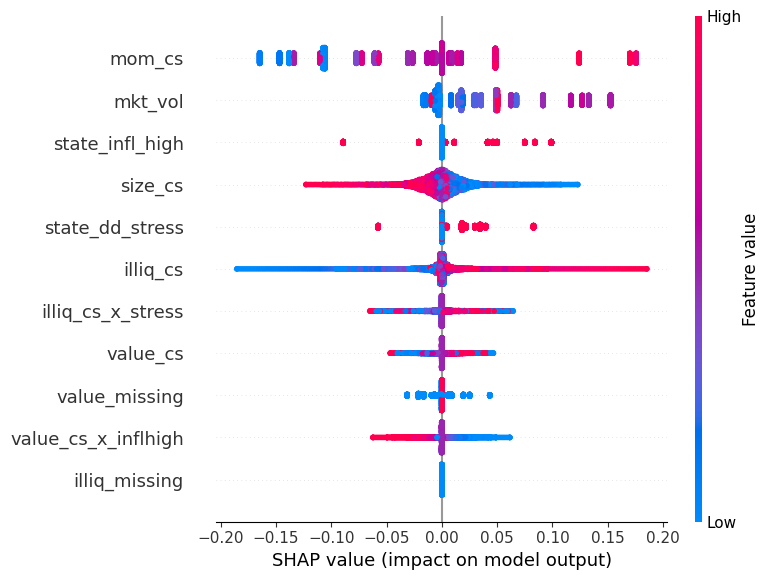

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


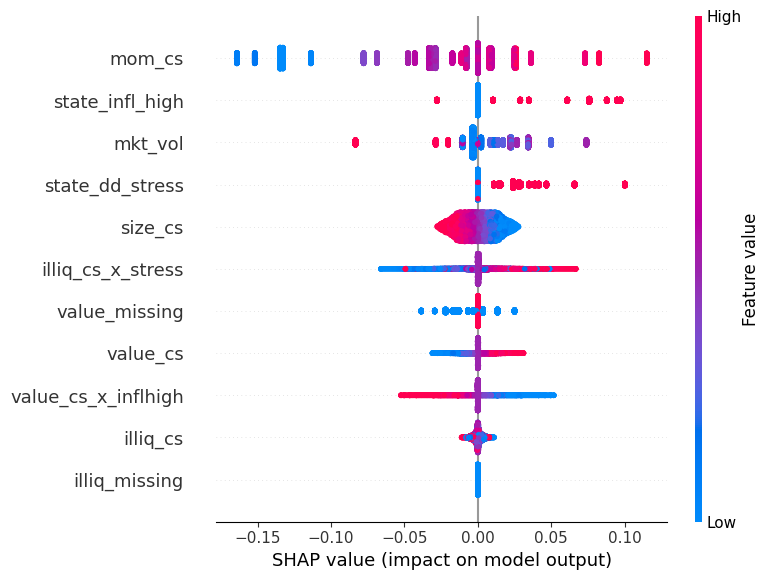

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


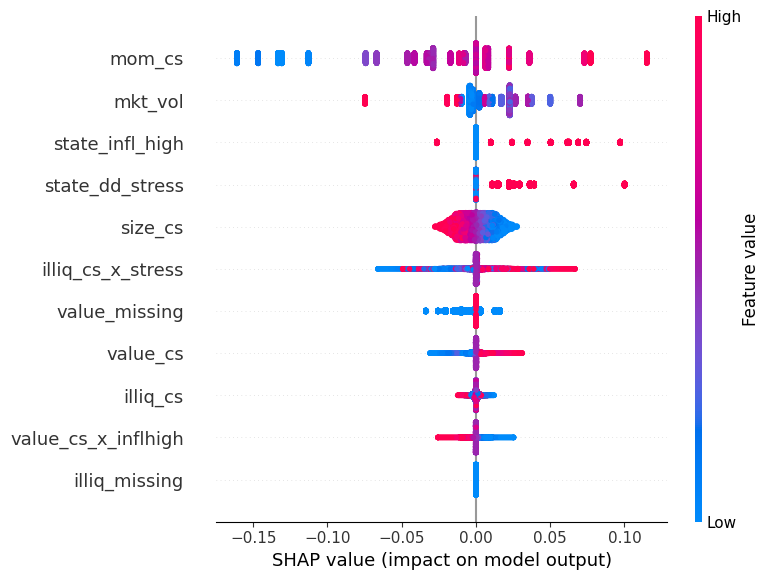

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


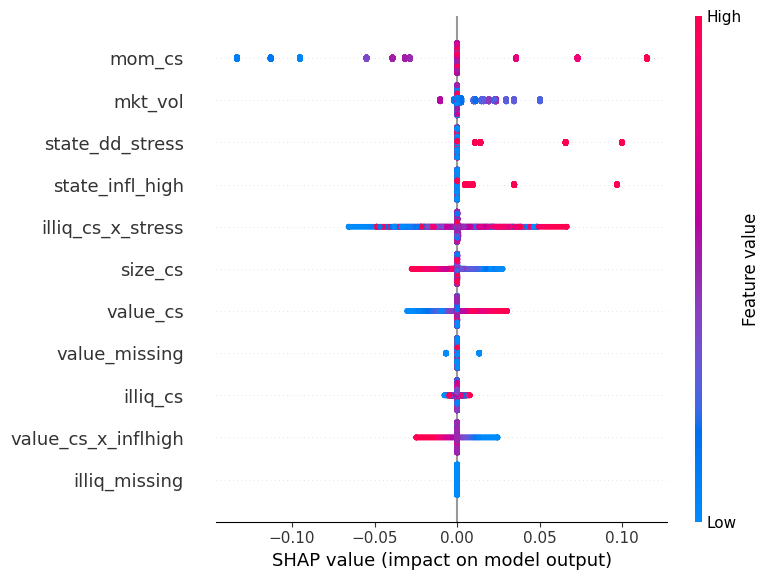

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


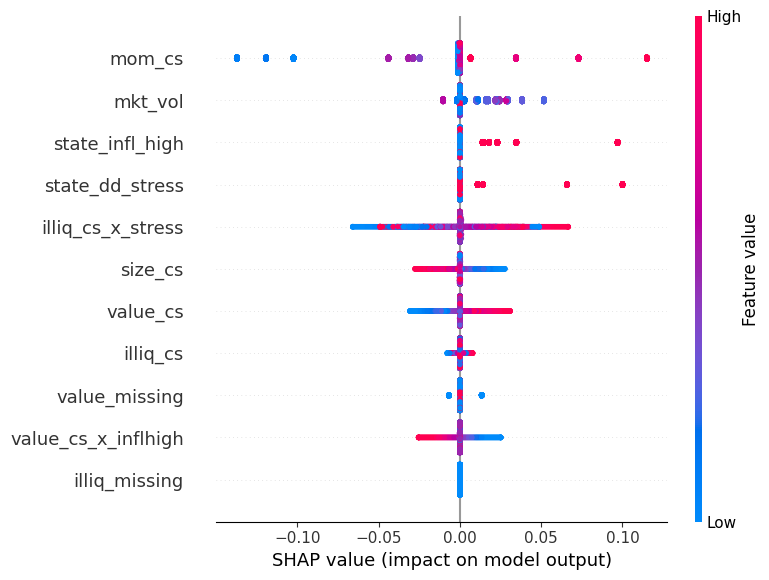

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


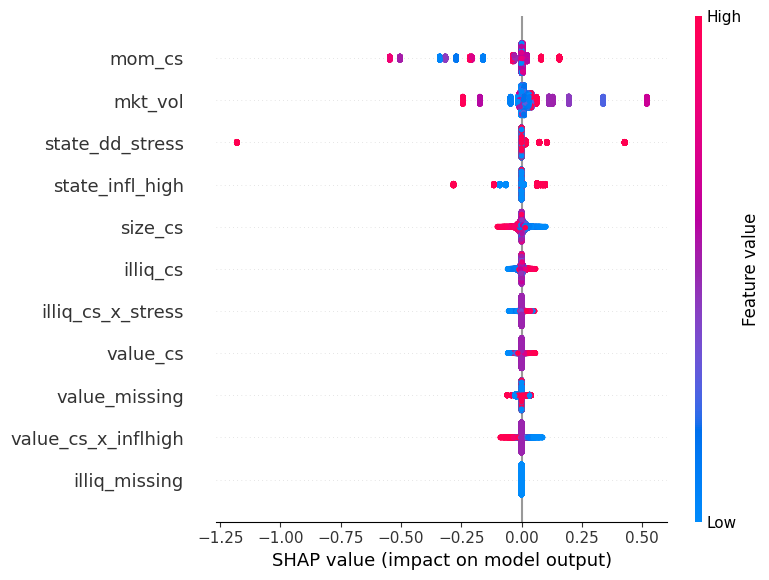

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


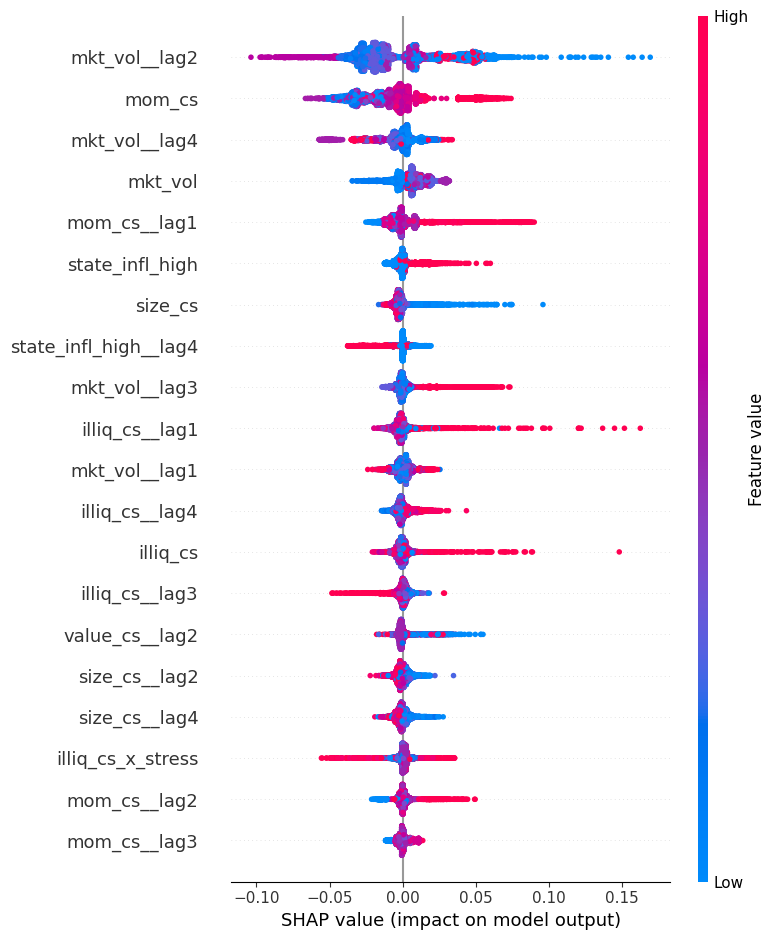

/tmp/ipykernel_2615/1558116068.py:116: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


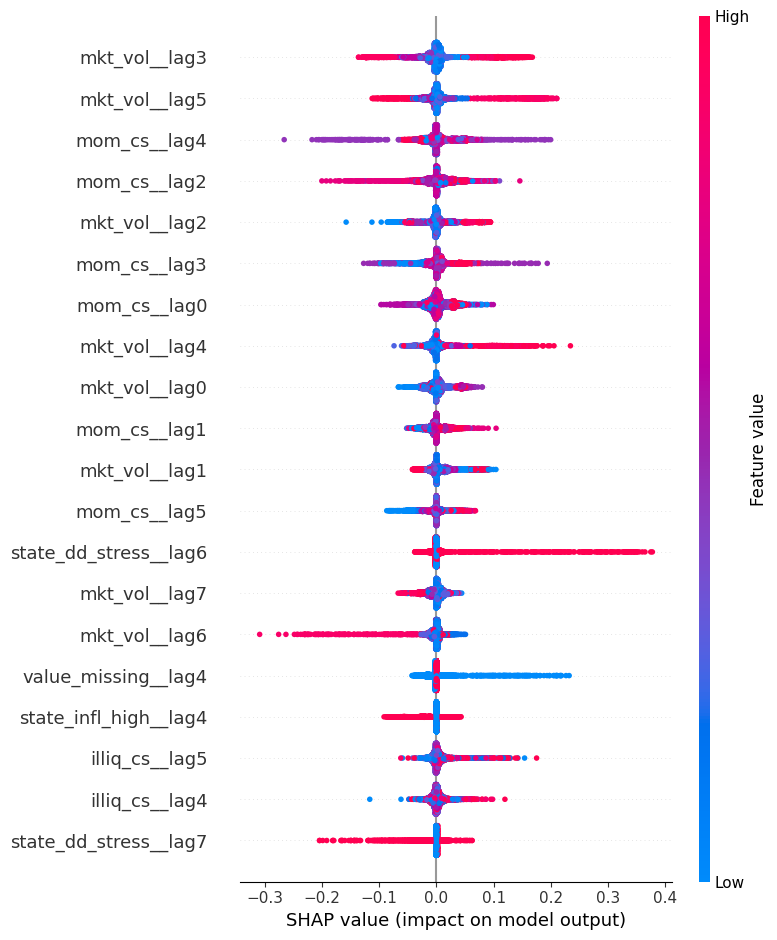

In [11]:

pipeline.plot_shap_summaries(results["shap_payload"])


## Phase 4. Block 3 selector, portfolio construction, and evaluation

Этот блок превращает прогнозы из Block 2 в три сравнимые инвестиционные политики:

1. `always_linear` — всегда использует линейный класс модели.
2. `always_transformer` — всегда использует Transformer/PatchTST-класс модели.
3. `selector_based` — выбирает класс модели по наблюдаемым состояниям рынка на дату ребалансировки.

Для всех стратегий используется один и тот же long-only mean-variance optimizer. Отличается только вектор ожидаемой доходности: он берётся из reliability-scaled прогноза `prediction_scaled`, а если такой колонки нет — из обычного `prediction`.


In [19]:
# ============================================================
# Phase 4 / Block 3
# Selector, portfolio construction, and evaluation
# ============================================================

from typing import Dict, Iterable, List, Optional, Sequence

import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# ---------
# Block 3 settings
# ---------
BLOCK3_LINEAR_MODEL_PREFERRED = "ridge"          # always-linear benchmark
BLOCK3_TRANSFORMER_MODEL_PREFERRED = "patchtst_global"  # always-transformer benchmark
BLOCK3_NONLINEAR_MODEL_PREFERRED = "catboost_lags_regimes"

BLOCK3_EXPECTED_RETURN_COL = "prediction_scaled"  # reliability-scaled forecast; fallback to raw prediction
BLOCK3_MAX_ASSETS = 25
BLOCK3_MIN_ASSETS = 5
BLOCK3_MAX_WEIGHT = 0.15
BLOCK3_RISK_AVERSION = 5.0
BLOCK3_COV_WINDOW = 24
BLOCK3_PERIODS_PER_YEAR = 4  # target_q_fwd_clean is a quarterly target
BLOCK3_VAR_ALPHA = 0.05
BLOCK3_BOOTSTRAP_N = 1000
BLOCK3_BOOTSTRAP_BLOCK_LEN = 4
BLOCK3_RANDOM_STATE = 42
# ---------
# Rule-based selector audit settings
# ---------
# ВАЖНО: это не "доказывает" ex ante автоматически.
# Если правило было придумано после просмотра результатов портфеля, оставь False.
# Если правило было зафиксировано до портфельного backtest, поставь True и укажи дату/версию.
BLOCK3_RULE_FIXED_EX_ANTE = False
BLOCK3_RULE_VERSION = "rule_based_v1"
BLOCK3_RULE_LOCK_DATE = None  # example: "2026-05-10"
BLOCK3_AFTER_2020_START = "2021-01-01"
# ---------
# Rolling composite selector settings
# ---------
BLOCK3_SELECTOR_LOOKBACK_PERIODS = 8      # 8 quarters
BLOCK3_SELECTOR_MIN_REGIME_PERIODS = 3    # минимум прошлых дат с таким же режимом
BLOCK3_SELECTOR_MIN_OBS = 20              # минимум строк для оценки модели

BLOCK3_SELECTOR_W_MSE = -0.5
BLOCK3_SELECTOR_W_SPEARMAN = 0.3
BLOCK3_SELECTOR_W_TAIL = -0.2

def _first_existing_col(df: pd.DataFrame, candidates: Sequence[str]) -> Optional[str]:
    for col in candidates:
        if col in df.columns:
            return col
    return None


def _infer_sector_col(df: pd.DataFrame) -> Optional[str]:
    return _first_existing_col(
        df,
        [
            "sector", "sector_name", "industry", "industry_name", "gics_sector",
            "economic_sector", "finam_sector", "moex_sector", "Sector", "Industry",
        ],
    )


def _detect_regime_cols(df: pd.DataFrame) -> List[str]:
    candidates = [
        "state_infl_high",
        "state_vol_high",
        "state_vol_stress",
        "state_volatility_high",
        "state_mkt_vol_high",
        "state_vol_high_auto",
        "state_dd_stress",
    ]
    return [col for col in candidates if col in df.columns]


def _add_auto_vol_regime_if_needed(
    df: pd.DataFrame,
    date_col: str,
    vol_col: str = "mkt_vol",
    out_col: str = "state_vol_high_auto",
    min_periods: int = 12,
    quantile: float = 0.75,
) -> pd.DataFrame:
    """
    Fallback volatility state for Block 3.
    If no precomputed volatility dummy exists, derive one from mkt_vol using only lagged expanding information.
    """
    out = df.copy()
    existing_vol_cols = [
        "state_vol_high",
        "state_vol_stress",
        "state_volatility_high",
        "state_mkt_vol_high",
    ]
    if any(col in out.columns for col in existing_vol_cols) or vol_col not in out.columns:
        return out

    date_vol = (
        out[[date_col, vol_col]]
        .dropna(subset=[date_col])
        .groupby(date_col, as_index=False)[vol_col]
        .median()
        .sort_values(date_col)
    )
    shifted = date_vol[vol_col].shift(1)
    threshold = shifted.expanding(min_periods=min_periods).quantile(quantile)
    date_vol[out_col] = (date_vol[vol_col] >= threshold).astype(float)
    date_vol.loc[threshold.isna(), out_col] = 0.0

    out = out.merge(date_vol[[date_col, out_col]], on=date_col, how="left")
    out[out_col] = out[out_col].fillna(0.0)
    return out


def _resolve_model_for_date(
    requested_model: str,
    available_models: Iterable[str],
    fallback_order: Sequence[str],
) -> str:
    available = list(available_models)
    if requested_model in available:
        return requested_model
    for model in fallback_order:
        if model in available:
            return model
    if not available:
        raise ValueError("No model forecasts are available for this rebalance date.")
    return available[0]


def _date_state_table(pred: pd.DataFrame, date_col: str, regime_cols: Sequence[str]) -> pd.DataFrame:
    cols = [date_col] + [col for col in regime_cols if col in pred.columns]
    if len(cols) == 1:
        return pred[[date_col]].drop_duplicates().sort_values(date_col)
    return (
        pred[cols]
        .drop_duplicates(subset=[date_col])
        .sort_values(date_col)
        .reset_index(drop=True)
    )


def _regime_signature_from_row(state_row: pd.Series, regime_cols: Sequence[str]) -> tuple:
    """
    Converts observable regime indicators into a binary regime signature.
    Example: (infl_high, vol_high, dd_stress) = (1, 0, 1)
    """
    signature = []
    for col in regime_cols:
        value = state_row.get(col, 0)
        try:
            value = float(value)
        except Exception:
            value = 0.0
        signature.append(int(value >= 0.5))
    return tuple(signature)


def _safe_cross_model_zscore(values: pd.Series) -> pd.Series:
    """
    z(x) across models at the same rebalance date.
    If dispersion is zero, returns zeros.
    """
    values = pd.to_numeric(values, errors="coerce")
    mean = values.mean()
    std = values.std(ddof=0)

    if not np.isfinite(std) or std <= 1e-12:
        return pd.Series(0.0, index=values.index)

    return (values - mean) / std


def _rule_based_selector_requested_model(
    state_row: pd.Series,
    linear_model: str,
    transformer_model: str,
    nonlinear_model: str,
) -> str:
    def _is_on(names):
        for name in names:
            value = state_row.get(name, 0)
            try:
                if float(value) >= 0.5:
                    return True
            except Exception:
                pass
        return False

    drawdown_stress = _is_on([
        "state_dd_stress",
        "dd_stress",
        "drawdown_stress",
    ])

    volatility_stress = _is_on([
        "state_vol_high",
        "state_vol_stress",
        "state_volatility_high",
        "state_mkt_vol_high",
        "state_vol_high_auto",
    ])

    inflation_high = _is_on([
        "state_infl_high",
        "infl_high",
        "inflation_high",
    ])

    if drawdown_stress or volatility_stress:
        return transformer_model

    if inflation_high:
        return nonlinear_model

    return linear_model

def _rolling_composite_selector_requested_model(
    pred: pd.DataFrame,
    current_date: pd.Timestamp,
    state_row: pd.Series,
    date_col: str,
    id_col: str,
    target_col: str,
    expected_col: str,
    regime_cols: Sequence[str],
    available_models: Iterable[str],
    fallback_model: str,
    lookback_periods: int = BLOCK3_SELECTOR_LOOKBACK_PERIODS,
    min_regime_periods: int = BLOCK3_SELECTOR_MIN_REGIME_PERIODS,
    min_obs: int = BLOCK3_SELECTOR_MIN_OBS,
) -> tuple[str, dict]:
    """
    Rolling out-of-sample, regime-aware selector.

    At rebalance date t:
    1. use only past forecast history;
    2. optionally keep only past dates with the same regime signature;
    3. compute rolling MSE, rolling Spearman and tail-instability;
    4. standardize metrics across models at date t;
    5. select the model with the highest composite score.

    Score_m,t =
        -0.5 z(MSE_m,t)
        +0.3 z(Spearman_m,t)
        -0.2 z(TailRatio_m,t)
    """
    current_date = pd.Timestamp(current_date)
    available_models = set(str(m) for m in available_models)

    hist = pred.loc[
        (pred[date_col] < current_date)
        & (pred["model"].astype(str).isin(available_models))
    ].copy()

    if hist.empty:
        return fallback_model, {
            "selector_scope": "fallback_no_history",
            "selector_score": np.nan,
            "selector_mse": np.nan,
            "selector_spearman": np.nan,
            "selector_tail_ratio": np.nan,
            "selector_n_dates": 0,
            "selector_n_obs": 0,
        }

    # keep only the latest rolling window of past rebalance dates
    past_dates = sorted(pd.to_datetime(hist[date_col].dropna().unique()))
    past_dates = past_dates[-lookback_periods:]
    hist = hist.loc[hist[date_col].isin(past_dates)].copy()

    selector_scope = "global_rolling"

    # Regime-conditional filtering: use past dates with the same regime signature if enough exist
    if regime_cols:
        current_signature = _regime_signature_from_row(state_row, regime_cols)

        date_state = (
            hist[[date_col] + [c for c in regime_cols if c in hist.columns]]
            .drop_duplicates(subset=[date_col])
            .copy()
        )

        matched_dates = []
        for _, row in date_state.iterrows():
            if _regime_signature_from_row(row, regime_cols) == current_signature:
                matched_dates.append(pd.Timestamp(row[date_col]))

        if len(matched_dates) >= min_regime_periods:
            hist_regime = hist.loc[hist[date_col].isin(matched_dates)].copy()
            if not hist_regime.empty:
                hist = hist_regime
                selector_scope = "regime_conditional"

    rows = []

    for model, grp in hist.groupby("model"):
        model = str(model)
        grp = grp.copy()

        grp[expected_col] = pd.to_numeric(grp[expected_col], errors="coerce")
        grp[target_col] = pd.to_numeric(grp[target_col], errors="coerce")
        grp = grp.dropna(subset=[expected_col, target_col])

        if len(grp) < min_obs:
            continue

        grp["squared_error"] = (grp[expected_col] - grp[target_col]) ** 2

        # Date-level MSE, then average over rolling window
        date_mse = grp.groupby(date_col)["squared_error"].mean().replace([np.inf, -np.inf], np.nan).dropna()
        if date_mse.empty:
            continue

        mse_roll = float(date_mse.mean())

        # Tail instability: mean MSE / median MSE.
        # If tail errors are large, mean becomes much larger than median, so TailRatio rises.
        median_mse = float(date_mse.median())
        if not np.isfinite(median_mse) or median_mse <= 1e-12:
            tail_ratio = np.nan
        else:
            tail_ratio = float(date_mse.mean() / median_mse)

        # Cross-sectional Spearman by date, then average
        spearman_values = []
        for _, g in grp.groupby(date_col):
            if len(g) < 3:
                continue
            if g[expected_col].nunique() < 2 or g[target_col].nunique() < 2:
                continue
            corr = g[expected_col].corr(g[target_col], method="spearman")
            if np.isfinite(corr):
                spearman_values.append(float(corr))

        spearman_roll = float(np.mean(spearman_values)) if spearman_values else np.nan

        rows.append({
            "model": model,
            "mse_roll": mse_roll,
            "spearman_roll": spearman_roll,
            "tail_ratio_roll": tail_ratio,
            "n_dates": int(grp[date_col].nunique()),
            "n_obs": int(len(grp)),
        })

    score_df = pd.DataFrame(rows)

    if score_df.empty:
        return fallback_model, {
            "selector_scope": "fallback_no_valid_scores",
            "selector_score": np.nan,
            "selector_mse": np.nan,
            "selector_spearman": np.nan,
            "selector_tail_ratio": np.nan,
            "selector_n_dates": int(hist[date_col].nunique()),
            "selector_n_obs": int(len(hist)),
        }

    # Missing Spearman is treated as neutral after z-scoring
    for col in ["mse_roll", "spearman_roll", "tail_ratio_roll"]:
        if score_df[col].notna().any():
            score_df[col] = score_df[col].fillna(score_df[col].median())
        else:
            score_df[col] = 0.0

    score_df["z_mse"] = _safe_cross_model_zscore(score_df["mse_roll"])
    score_df["z_spearman"] = _safe_cross_model_zscore(score_df["spearman_roll"])
    score_df["z_tail_ratio"] = _safe_cross_model_zscore(score_df["tail_ratio_roll"])

    score_df["selector_score"] = (
        BLOCK3_SELECTOR_W_MSE * score_df["z_mse"]
        + BLOCK3_SELECTOR_W_SPEARMAN * score_df["z_spearman"]
        + BLOCK3_SELECTOR_W_TAIL * score_df["z_tail_ratio"]
    )

    best = score_df.sort_values("selector_score", ascending=False).iloc[0]

    return str(best["model"]), {
        "selector_scope": selector_scope,
        "selector_score": float(best["selector_score"]),
        "selector_mse": float(best["mse_roll"]),
        "selector_spearman": float(best["spearman_roll"]),
        "selector_tail_ratio": float(best["tail_ratio_roll"]),
        "selector_n_dates": int(best["n_dates"]),
        "selector_n_obs": int(best["n_obs"]),
    }


def _build_return_matrix(
    panel: pd.DataFrame,
    id_col: str,
    date_col: str,
    target_col: str,
) -> pd.DataFrame:
    tmp = panel[[date_col, id_col, target_col]].copy()
    tmp[date_col] = pd.to_datetime(tmp[date_col])
    tmp[target_col] = pd.to_numeric(tmp[target_col], errors="coerce")
    return tmp.pivot_table(index=date_col, columns=id_col, values=target_col, aggfunc="mean").sort_index()


def _covariance_for_assets(
    return_matrix: pd.DataFrame,
    assets: Sequence[str],
    state_date: pd.Timestamp,
    window: int,
) -> pd.DataFrame:
    available_assets = [asset for asset in assets if asset in return_matrix.columns]
    if not available_assets:
        return pd.DataFrame()

    hist = return_matrix.loc[return_matrix.index <= pd.Timestamp(state_date), available_assets].tail(window)
    hist = hist.dropna(axis=1, how="all")
    if hist.shape[1] == 0:
        return pd.DataFrame()

    cov = hist.cov(min_periods=2)
    # Fill sparse covariances conservatively: zero covariance, asset-level variance on diagonal.
    fallback_var = hist.var(skipna=True).replace([np.inf, -np.inf], np.nan)
    global_var = float(np.nanmedian(fallback_var.to_numpy())) if fallback_var.notna().any() else 1e-4
    if not np.isfinite(global_var) or global_var <= 0:
        global_var = 1e-4

    cov = cov.reindex(index=hist.columns, columns=hist.columns).fillna(0.0)
    for asset in cov.columns:
        var = fallback_var.get(asset, np.nan)
        if not np.isfinite(var) or var <= 0:
            var = global_var
        cov.loc[asset, asset] = max(float(var), 1e-8)
    return cov


def _fallback_rank_weights(mu: pd.Series, max_assets: int, max_weight: float) -> pd.Series:
    mu = mu.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if mu.empty:
        return pd.Series(dtype=float)

    selected = mu.sort_values(ascending=False).head(max_assets)
    shifted = selected - selected.min()
    if np.isclose(float(shifted.sum()), 0.0):
        raw = pd.Series(1.0, index=selected.index)
    else:
        raw = shifted + 1e-12

    weights = raw / raw.sum()
    cap = max(max_weight, 1.0 / len(weights))
    # Simple cap-and-redistribute loop.
    for _ in range(20):
        over = weights > cap
        if not over.any():
            break
        excess = float((weights.loc[over] - cap).sum())
        weights.loc[over] = cap
        under = ~over
        if not under.any() or weights.loc[under].sum() <= 0:
            break
        weights.loc[under] += excess * weights.loc[under] / weights.loc[under].sum()
    return weights / weights.sum()


def _optimize_long_only_mean_variance(
    mu: pd.Series,
    cov: pd.DataFrame,
    max_assets: int = 25,
    min_assets: int = 5,
    max_weight: float = 0.15,
    risk_aversion: float = 5.0,
) -> pd.Series:
    """
    Long-only constrained mean-variance optimisation.
    The same optimiser is used for all strategies; only mu changes.
    """
    mu = mu.replace([np.inf, -np.inf], np.nan).dropna().astype(float)
    if mu.empty:
        return pd.Series(dtype=float)

    selected = mu.sort_values(ascending=False).head(max_assets)
    if len(selected) < min_assets:
        selected = mu.sort_values(ascending=False).head(max(len(mu), len(selected)))

    if cov.empty:
        return _fallback_rank_weights(selected, max_assets=max_assets, max_weight=max_weight)

    common_assets = [asset for asset in selected.index if asset in cov.index and asset in cov.columns]
    if len(common_assets) < 2:
        return _fallback_rank_weights(selected, max_assets=max_assets, max_weight=max_weight)

    selected = selected.loc[common_assets]
    sigma = cov.loc[common_assets, common_assets].to_numpy(dtype=float)
    sigma = np.nan_to_num((sigma + sigma.T) / 2.0, nan=0.0, posinf=0.0, neginf=0.0)
    sigma = sigma + np.eye(len(common_assets)) * 1e-8
    mu_vec = selected.to_numpy(dtype=float)

    n = len(common_assets)
    cap = max(float(max_weight), 1.0 / n)
    bounds = [(0.0, cap) for _ in range(n)]
    constraints = [{"type": "eq", "fun": lambda w: float(np.sum(w) - 1.0)}]
    x0 = np.repeat(1.0 / n, n)

    def objective(w: np.ndarray) -> float:
        expected = float(w @ mu_vec)
        risk = float(w @ sigma @ w)
        return -(expected - 0.5 * risk_aversion * risk)

    result = minimize(
        objective,
        x0=x0,
        method="SLSQP",
        bounds=bounds,
        constraints=constraints,
        options={"maxiter": 500, "ftol": 1e-10, "disp": False},
    )

    if (not result.success) or (not np.all(np.isfinite(result.x))):
        return _fallback_rank_weights(selected, max_assets=max_assets, max_weight=max_weight)

    weights = pd.Series(result.x, index=common_assets, dtype=float)
    weights = weights.clip(lower=0.0)
    if weights.sum() <= 0:
        return _fallback_rank_weights(selected, max_assets=max_assets, max_weight=max_weight)
    weights = weights / weights.sum()
    return weights[weights > 1e-10]


def _performance_metrics(
    returns: Sequence[float],
    periods_per_year: int = 4,
    var_alpha: float = 0.05,
) -> Dict[str, float]:
    r = pd.Series(returns, dtype=float).replace([np.inf, -np.inf], np.nan).dropna()
    n = int(len(r))
    if n == 0:
        return {
            "n_periods": 0,
            "mean_return": np.nan,
            "annualized_return": np.nan,
            "annualized_vol": np.nan,
            "sharpe": np.nan,
            "sortino": np.nan,
            "max_drawdown": np.nan,
            "calmar": np.nan,
            "var_5_return": np.nan,
            "cvar_5_return": np.nan,
        }

    mean_return = float(r.mean())
    vol = float(r.std(ddof=1)) if n > 1 else np.nan
    annualized_vol = vol * np.sqrt(periods_per_year) if np.isfinite(vol) else np.nan

    cumulative = (1.0 + r).cumprod()
    total_return = float(cumulative.iloc[-1] - 1.0)
    if cumulative.iloc[-1] > 0:
        annualized_return = float(cumulative.iloc[-1] ** (periods_per_year / n) - 1.0)
    else:
        annualized_return = np.nan

    running_peak = cumulative.cummax()
    drawdown = cumulative / running_peak - 1.0
    max_drawdown = float(drawdown.min())

    downside = r.where(r < 0).dropna()
    downside_std = float(downside.std(ddof=1)) if len(downside) > 1 else np.nan
    annualized_downside = downside_std * np.sqrt(periods_per_year) if np.isfinite(downside_std) else np.nan

    sharpe = annualized_return / annualized_vol if annualized_vol and annualized_vol > 0 else np.nan
    sortino = annualized_return / annualized_downside if annualized_downside and annualized_downside > 0 else np.nan
    calmar = annualized_return / abs(max_drawdown) if max_drawdown < 0 else np.nan

    var_value = float(r.quantile(var_alpha))
    cvar_sample = r.loc[r <= var_value]
    cvar_value = float(cvar_sample.mean()) if len(cvar_sample) else var_value

    return {
        "n_periods": n,
        "mean_return": mean_return,
        "annualized_return": annualized_return,
        "annualized_vol": annualized_vol,
        "sharpe": sharpe,
        "sortino": sortino,
        "max_drawdown": max_drawdown,
        "calmar": calmar,
        "var_5_return": var_value,
        "cvar_5_return": cvar_value,
    }


def _summarise_returns(
    df: pd.DataFrame,
    group_cols: Sequence[str],
    return_col: str,
    periods_per_year: int,
    var_alpha: float,
) -> pd.DataFrame:
    rows = []
    for key, grp in df.groupby(list(group_cols), dropna=False):
        if not isinstance(key, tuple):
            key = (key,)
        row = {col: value for col, value in zip(group_cols, key)}
        row.update(_performance_metrics(grp[return_col], periods_per_year, var_alpha))
        rows.append(row)
    return pd.DataFrame(rows)


def _block_bootstrap_bands(
    portfolio_returns: pd.DataFrame,
    return_col: str = "portfolio_return",
    strategy_col: str = "strategy",
    date_col: str = "forecast_date",
    n_boot: int = 1000,
    block_len: int = 4,
    periods_per_year: int = 4,
    var_alpha: float = 0.05,
    random_state: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_state)
    metric_cols = [
        "mean_return",
        "annualized_return",
        "annualized_vol",
        "sharpe",
        "sortino",
        "max_drawdown",
        "calmar",
        "var_5_return",
        "cvar_5_return",
    ]
    rows = []

    for strategy, grp in portfolio_returns.sort_values(date_col).groupby(strategy_col):
        r = grp[return_col].replace([np.inf, -np.inf], np.nan).dropna().to_numpy(dtype=float)
        n = len(r)
        if n == 0:
            continue
        actual_block_len = max(1, min(block_len, n))
        starts = np.arange(0, n - actual_block_len + 1)
        if len(starts) == 0:
            starts = np.array([0])

        boot_metrics = []
        for _ in range(n_boot):
            sampled = []
            while len(sampled) < n:
                start = int(rng.choice(starts))
                sampled.extend(r[start:start + actual_block_len].tolist())
            sampled = sampled[:n]
            boot_metrics.append(_performance_metrics(sampled, periods_per_year, var_alpha))

        boot_df = pd.DataFrame(boot_metrics)
        for metric in metric_cols:
            values = boot_df[metric].replace([np.inf, -np.inf], np.nan).dropna()
            if values.empty:
                rows.append({
                    strategy_col: strategy,
                    "metric": metric,
                    "ci_low": np.nan,
                    "median": np.nan,
                    "ci_high": np.nan,
                    "n_bootstrap": n_boot,
                    "block_len": actual_block_len,
                })
            else:
                rows.append({
                    strategy_col: strategy,
                    "metric": metric,
                    "ci_low": float(values.quantile(0.025)),
                    "median": float(values.quantile(0.500)),
                    "ci_high": float(values.quantile(0.975)),
                    "n_bootstrap": n_boot,
                    "block_len": actual_block_len,
                })
    return pd.DataFrame(rows)

def _make_rule_based_ex_ante_audit(
    regime_cols: Sequence[str],
    linear_model: str,
    transformer_model: str,
    nonlinear_model: str,
) -> pd.DataFrame:
    """
    Audit table for the rule-based selector.

    This table does not prove that the rule was fixed ex ante.
    It documents whether the notebook declares the rule as fixed before the portfolio backtest
    and which observable state variables enter the rule.
    """
    return pd.DataFrame([
        {
            "rule_name": "selector_rule_based",
            "rule_version": BLOCK3_RULE_VERSION,
            "declared_fixed_ex_ante": bool(BLOCK3_RULE_FIXED_EX_ANTE),
            "rule_lock_date": BLOCK3_RULE_LOCK_DATE,
            "uses_realized_portfolio_returns": False,
            "uses_future_returns": False,
            "uses_forecast_values": False,
            "uses_observable_regime_states": True,
            "regime_inputs_available": ", ".join(regime_cols),
            "linear_model": linear_model,
            "transformer_model": transformer_model,
            "nonlinear_model": nonlinear_model,
            "interpretation": (
                "Strong evidence only if declared_fixed_ex_ante=True and the rule was fixed "
                "before running portfolio backtest. Otherwise treat selector result as provisional."
            ),
        }
    ])


def _post2020_selector_vs_transformer_diagnostics(
    portfolio_returns: pd.DataFrame,
    selector_log: pd.DataFrame,
    after_date: str = BLOCK3_AFTER_2020_START,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Compare selector_rule_based against always_transformer after 2020.

    Separates:
    1. dates where selector_rule_based is literally identical to always_transformer;
    2. switching dates where selector_rule_based uses another model.
    """
    if portfolio_returns.empty or selector_log.empty:
        return pd.DataFrame(), pd.DataFrame()

    pr = portfolio_returns.copy()
    pr["forecast_date"] = pd.to_datetime(pr["forecast_date"])

    sl = selector_log.copy()
    sl["forecast_date"] = pd.to_datetime(sl["forecast_date"])

    pr = pr.loc[
        (pr["forecast_date"] >= pd.Timestamp(after_date))
        & (pr["strategy"].isin(["selector_rule_based", "always_transformer"]))
    ].copy()

    if pr.empty:
        return pd.DataFrame(), pd.DataFrame()

    ret_wide = (
        pr.pivot_table(
            index="forecast_date",
            columns="strategy",
            values="portfolio_return",
            aggfunc="first",
        )
        .reset_index()
    )

    model_wide = (
        sl.loc[
            (sl["forecast_date"] >= pd.Timestamp(after_date))
            & (sl["strategy"].isin(["selector_rule_based", "always_transformer"])),
            ["forecast_date", "strategy", "model_used"],
        ]
        .pivot_table(
            index="forecast_date",
            columns="strategy",
            values="model_used",
            aggfunc="first",
        )
        .reset_index()
        .rename(columns={
            "selector_rule_based": "selector_model_used",
            "always_transformer": "transformer_model_used",
        })
    )

    detail = ret_wide.merge(model_wide, on="forecast_date", how="left")
    if "selector_rule_based" not in detail.columns or "always_transformer" not in detail.columns:
        return pd.DataFrame(), pd.DataFrame()

    detail["return_diff_selector_minus_transformer"] = (
        detail["selector_rule_based"] - detail["always_transformer"]
    )
    detail["selector_same_as_transformer"] = (
        detail["selector_model_used"].astype(str)
        == detail["transformer_model_used"].astype(str)
    )
    detail["period_type"] = np.where(
        detail["selector_same_as_transformer"],
        "identical_to_transformer",
        "switch_away_from_transformer",
    )

    rows = []
    for label, grp in [("all_after_2020", detail)] + list(detail.groupby("period_type")):
        if grp.empty:
            continue

        selector_cum = float((1.0 + grp["selector_rule_based"]).prod() - 1.0)
        transformer_cum = float((1.0 + grp["always_transformer"]).prod() - 1.0)
        diff = grp["return_diff_selector_minus_transformer"]

        rows.append({
            "sample": label,
            "n_quarters": int(len(grp)),
            "n_identical_to_transformer": int(grp["selector_same_as_transformer"].sum()),
            "n_switch_away_from_transformer": int((~grp["selector_same_as_transformer"]).sum()),
            "mean_selector_return": float(grp["selector_rule_based"].mean()),
            "mean_transformer_return": float(grp["always_transformer"].mean()),
            "mean_diff_selector_minus_transformer": float(diff.mean()),
            "median_diff_selector_minus_transformer": float(diff.median()),
            "hit_rate_selector_gt_transformer": float((diff > 0).mean()),
            "cumulative_selector_return": selector_cum,
            "cumulative_transformer_return": transformer_cum,
            "cumulative_diff_selector_minus_transformer": selector_cum - transformer_cum,
        })

    summary = pd.DataFrame(rows)
    return detail.sort_values("forecast_date").reset_index(drop=True), summary


def _holdings_turnover_diagnostics(
    holdings: pd.DataFrame,
    id_col: str,
) -> pd.DataFrame:
    """
    Computes date-to-date portfolio turnover for every strategy.

    turnover = 1 - sum_i min(w_{i,t}, w_{i,t-1})
    """
    if holdings.empty:
        return pd.DataFrame()

    h = holdings.copy()
    h["forecast_date"] = pd.to_datetime(h["forecast_date"])
    h["weight"] = pd.to_numeric(h["weight"], errors="coerce").fillna(0.0)

    rows = []

    for strategy, grp in h.groupby("strategy"):
        prev_weights = None

        for date, g in grp.sort_values("forecast_date").groupby("forecast_date"):
            current_weights = g.groupby(id_col)["weight"].sum()

            if prev_weights is None:
                turnover = np.nan
                n_entered = np.nan
                n_exited = np.nan
            else:
                all_assets = current_weights.index.union(prev_weights.index)
                current_aligned = current_weights.reindex(all_assets, fill_value=0.0)
                prev_aligned = prev_weights.reindex(all_assets, fill_value=0.0)

                overlap = np.minimum(current_aligned, prev_aligned).sum()
                turnover = float(1.0 - overlap)

                n_entered = int(((current_aligned > 0) & (prev_aligned <= 0)).sum())
                n_exited = int(((current_aligned <= 0) & (prev_aligned > 0)).sum())

            rows.append({
                "strategy": strategy,
                "forecast_date": date,
                "turnover": turnover,
                "n_entered": n_entered,
                "n_exited": n_exited,
                "n_assets": int(current_weights.gt(0).sum()),
            })

            prev_weights = current_weights

    return pd.DataFrame(rows)


def _patchtst_selected_concentration_diagnostics(
    holdings: pd.DataFrame,
    selector_log: pd.DataFrame,
    transformer_model: str,
    id_col: str,
    target_col: str,
    after_date: str = BLOCK3_AFTER_2020_START,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    Concentration diagnostics for quarters where selector_rule_based selected PatchTST / transformer.

    Checks:
    - concentration of weights;
    - concentration of realized return contribution;
    - whether a few names drive the result.
    """
    if holdings.empty or selector_log.empty:
        return pd.DataFrame(), pd.DataFrame()

    sl = selector_log.copy()
    sl["forecast_date"] = pd.to_datetime(sl["forecast_date"])

    patch_dates = sl.loc[
        (sl["strategy"] == "selector_rule_based")
        & (sl["model_used"].astype(str) == str(transformer_model))
        & (sl["forecast_date"] >= pd.Timestamp(after_date)),
        "forecast_date",
    ].drop_duplicates()

    if patch_dates.empty:
        return pd.DataFrame(), pd.DataFrame()

    h = holdings.copy()
    h["forecast_date"] = pd.to_datetime(h["forecast_date"])

    h = h.loc[
        (h["strategy"] == "selector_rule_based")
        & (h["forecast_date"].isin(patch_dates))
    ].copy()

    if h.empty:
        return pd.DataFrame(), pd.DataFrame()

    h["weight"] = pd.to_numeric(h["weight"], errors="coerce").fillna(0.0)
    h["weighted_realized_return"] = pd.to_numeric(
        h["weighted_realized_return"],
        errors="coerce",
    ).fillna(0.0)
    h["abs_contribution"] = h["weighted_realized_return"].abs()

    date_rows = []

    for date, g in h.groupby("forecast_date"):
        weights = g["weight"].sort_values(ascending=False)
        abs_contrib = g["abs_contribution"].sort_values(ascending=False)

        weight_hhi = float((weights ** 2).sum())
        effective_n = float(1.0 / weight_hhi) if weight_hhi > 0 else np.nan

        total_abs_contrib = float(abs_contrib.sum())
        top1_abs_contrib_share = (
            float(abs_contrib.iloc[0] / total_abs_contrib)
            if total_abs_contrib > 0 and len(abs_contrib) > 0
            else np.nan
        )
        top5_abs_contrib_share = (
            float(abs_contrib.iloc[:5].sum() / total_abs_contrib)
            if total_abs_contrib > 0
            else np.nan
        )

        top_asset_row = g.loc[g["abs_contribution"].idxmax()] if total_abs_contrib > 0 else None

        date_rows.append({
            "forecast_date": date,
            "n_assets": int(g[id_col].nunique()),
            "portfolio_return": float(g["weighted_realized_return"].sum()),
            "max_weight": float(weights.max()),
            "top5_weight": float(weights.iloc[:5].sum()),
            "weight_hhi": weight_hhi,
            "effective_n_assets": effective_n,
            "top1_abs_contribution_share": top1_abs_contrib_share,
            "top5_abs_contribution_share": top5_abs_contrib_share,
            "top_abs_contributor": top_asset_row[id_col] if top_asset_row is not None else np.nan,
            "top_abs_contribution": float(top_asset_row["weighted_realized_return"]) if top_asset_row is not None else np.nan,
        })

    date_concentration = pd.DataFrame(date_rows).sort_values("forecast_date")

    asset_drivers = (
        h.groupby(id_col, as_index=False)
        .agg(
            n_patchtst_quarters=("forecast_date", "nunique"),
            total_contribution=("weighted_realized_return", "sum"),
            total_abs_contribution=("abs_contribution", "sum"),
            avg_weight=("weight", "mean"),
            max_weight=("weight", "max"),
        )
        .sort_values("total_abs_contribution", ascending=False)
        .reset_index(drop=True)
    )

    total_abs = asset_drivers["total_abs_contribution"].sum()
    if total_abs > 0:
        asset_drivers["abs_contribution_share"] = asset_drivers["total_abs_contribution"] / total_abs
        asset_drivers["cum_abs_contribution_share"] = asset_drivers["abs_contribution_share"].cumsum()
    else:
        asset_drivers["abs_contribution_share"] = np.nan
        asset_drivers["cum_abs_contribution_share"] = np.nan

    return date_concentration.reset_index(drop=True), asset_drivers


def _selector_switch_regime_diagnostics(
    selector_log: pd.DataFrame,
    regime_cols: Sequence[str],
    after_date: str = BLOCK3_AFTER_2020_START,
) -> pd.DataFrame:
    """
    Checks whether selector switches happen around regime breaks.
    """
    if selector_log.empty:
        return pd.DataFrame()

    sl = selector_log.copy()
    sl["forecast_date"] = pd.to_datetime(sl["forecast_date"])

    rb = (
        sl.loc[
            (sl["strategy"] == "selector_rule_based")
            & (sl["forecast_date"] >= pd.Timestamp(after_date))
        ]
        .sort_values("forecast_date")
        .copy()
    )

    if rb.empty:
        return pd.DataFrame()

    rb["prev_model_used"] = rb["model_used"].shift(1)
    rb["model_switch"] = rb["model_used"].astype(str) != rb["prev_model_used"].astype(str)
    rb.loc[rb["prev_model_used"].isna(), "model_switch"] = False

    existing_regime_cols = [c for c in regime_cols if c in rb.columns]

    rb["regime_break"] = False
    for col in existing_regime_cols:
        rb[f"prev_{col}"] = rb[col].shift(1)
        rb[f"{col}_changed"] = rb[col] != rb[f"prev_{col}"]
        rb.loc[rb[f"prev_{col}"].isna(), f"{col}_changed"] = False
        rb["regime_break"] = rb["regime_break"] | rb[f"{col}_changed"].fillna(False)

    rb["switch_around_regime_break"] = rb["model_switch"] & rb["regime_break"]

    keep_cols = [
        "forecast_date",
        "model_used",
        "prev_model_used",
        "model_switch",
        "regime_break",
        "switch_around_regime_break",
    ]
    keep_cols += existing_regime_cols
    keep_cols += [f"{col}_changed" for col in existing_regime_cols]

    return rb[keep_cols].reset_index(drop=True)


def _bootstrap_ci_overlap_diagnostics(
    bootstrap_bands: pd.DataFrame,
    selector_strategy: str = "selector_rule_based",
    benchmark_strategies: Sequence[str] = ("always_linear", "always_transformer"),
) -> pd.DataFrame:
    """
    Checks whether selector confidence intervals materially dominate benchmarks.

    material_dominance=True only when selector CI low is above benchmark CI high.
    heavy_overlap=True when the CI overlap is large relative to the narrower interval.
    """
    if bootstrap_bands.empty:
        return pd.DataFrame()

    b = bootstrap_bands.copy()

    rows = []

    for metric in b["metric"].dropna().unique():
        selector_row = b.loc[
            (b["strategy"] == selector_strategy)
            & (b["metric"] == metric)
        ]

        if selector_row.empty:
            continue

        selector_row = selector_row.iloc[0]
        s_low = float(selector_row["ci_low"])
        s_med = float(selector_row["median"])
        s_high = float(selector_row["ci_high"])
        s_width = s_high - s_low

        for benchmark in benchmark_strategies:
            bench_row = b.loc[
                (b["strategy"] == benchmark)
                & (b["metric"] == metric)
            ]

            if bench_row.empty:
                continue

            bench_row = bench_row.iloc[0]
            b_low = float(bench_row["ci_low"])
            b_med = float(bench_row["median"])
            b_high = float(bench_row["ci_high"])
            b_width = b_high - b_low

            overlap_low = max(s_low, b_low)
            overlap_high = min(s_high, b_high)
            overlap_width = max(0.0, overlap_high - overlap_low)

            narrower_width = min(s_width, b_width)
            overlap_ratio_to_narrower = (
                overlap_width / narrower_width
                if narrower_width > 0
                else np.nan
            )

            rows.append({
                "metric": metric,
                "selector_strategy": selector_strategy,
                "benchmark_strategy": benchmark,
                "selector_ci_low": s_low,
                "selector_median": s_med,
                "selector_ci_high": s_high,
                "benchmark_ci_low": b_low,
                "benchmark_median": b_med,
                "benchmark_ci_high": b_high,
                "median_diff_selector_minus_benchmark": s_med - b_med,
                "ci_overlap_width": overlap_width,
                "ci_overlap_ratio_to_narrower": overlap_ratio_to_narrower,
                "selector_materially_dominates": bool(s_low > b_high),
                "benchmark_materially_dominates": bool(b_low > s_high),
                "heavy_overlap": bool(
                    np.isfinite(overlap_ratio_to_narrower)
                    and overlap_ratio_to_narrower >= 0.5
                ),
            })

    return pd.DataFrame(rows)

def run_phase4_block3(
    predictions: pd.DataFrame,
    panel: pd.DataFrame,
    cfg: ModelComparisonConfig,
    output_dir: str | Path,
) -> Dict[str, pd.DataFrame]:
    pred = predictions.copy()
    id_col = cfg.id_col
    date_col = cfg.date_col
    target_col = cfg.target_col

    pred[date_col] = pd.to_datetime(pred[date_col])
    if "forecast_date" not in pred.columns:
        pred["forecast_date"] = pred[date_col]
    pred["forecast_date"] = pd.to_datetime(pred["forecast_date"])

    expected_col = BLOCK3_EXPECTED_RETURN_COL if BLOCK3_EXPECTED_RETURN_COL in pred.columns else "prediction"
    pred["block3_expected_return"] = pd.to_numeric(pred[expected_col], errors="coerce")
    pred[target_col] = pd.to_numeric(pred[target_col], errors="coerce")

    sector_col = _infer_sector_col(pred)
    if sector_col is None:
        pred["block3_sector"] = "all"
        sector_col = "block3_sector"
    else:
        pred[sector_col] = pred[sector_col].fillna("unknown").astype(str)

    pred = _add_auto_vol_regime_if_needed(pred, date_col=date_col)
    regime_cols = _detect_regime_cols(pred)

    available_models = set(pred["model"].dropna().astype(str).unique())
    linear_model = _resolve_model_for_date(
        BLOCK3_LINEAR_MODEL_PREFERRED,
        available_models,
        fallback_order=["ridge", "elastic_net", "lasso", "ols", "rolling_ols", "kalman_tvp"],
    )
    transformer_model = _resolve_model_for_date(
        BLOCK3_TRANSFORMER_MODEL_PREFERRED,
        available_models,
        fallback_order=["patchtst_global", "catboost_lags_regimes", "rolling_ols", "ridge", "ols"],
    )
    nonlinear_model = _resolve_model_for_date(
        BLOCK3_NONLINEAR_MODEL_PREFERRED,
        available_models,
        fallback_order=["catboost_lags_regimes", transformer_model, linear_model],
    )

    # Risk model uses historical realised target returns only up to state_date.
    return_matrix = _build_return_matrix(panel, id_col=id_col, date_col=date_col, target_col=target_col)
    date_states = _date_state_table(pred, date_col=date_col, regime_cols=regime_cols)
    available_by_date = pred.groupby(date_col)["model"].apply(lambda x: set(x.astype(str))).to_dict()

    strategy_rows = []
    holding_rows = []
    selector_rows = []

    for forecast_date in sorted(pred[date_col].dropna().unique()):
        forecast_date = pd.Timestamp(forecast_date)
        date_available_models = available_by_date.get(forecast_date, available_models)
        state_rows = date_states.loc[date_states[date_col] == forecast_date]
        state_row = state_rows.iloc[0] if not state_rows.empty else pd.Series(dtype=float)

        rule_based_model = _rule_based_selector_requested_model(
            state_row=state_row,
            linear_model=linear_model,
            transformer_model=transformer_model,
            nonlinear_model=nonlinear_model,
        )

        composite_model, composite_diag = _rolling_composite_selector_requested_model(
            pred=pred,
            current_date=forecast_date,
            state_row=state_row,
            date_col=date_col,
            id_col=id_col,
            target_col=target_col,
            expected_col="block3_expected_return",
            regime_cols=regime_cols,
            available_models=date_available_models,
            fallback_model=linear_model,
        )

        requested_by_strategy = {
            "always_linear": linear_model,
            "always_transformer": transformer_model,
            "selector_rule_based": rule_based_model,
            "selector_composite": composite_model,
        }

        for strategy, requested_model in requested_by_strategy.items():
            model_used = _resolve_model_for_date(
                requested_model,
                date_available_models,
                fallback_order=[requested_model, transformer_model, nonlinear_model, linear_model, "ridge", "ols"],
            )
            date_pred = pred.loc[(pred[date_col] == forecast_date) & (pred["model"].astype(str) == model_used)].copy()
            date_pred = date_pred.dropna(subset=["block3_expected_return", target_col])
            if date_pred.empty:
                continue

            state_date = pd.Timestamp(date_pred["state_date"].dropna().iloc[0]) if "state_date" in date_pred.columns and date_pred["state_date"].notna().any() else forecast_date

            mu = date_pred.set_index(id_col)["block3_expected_return"]
            cov = _covariance_for_assets(return_matrix, mu.index.tolist(), state_date=state_date, window=BLOCK3_COV_WINDOW)
            weights = _optimize_long_only_mean_variance(
                mu=mu,
                cov=cov,
                max_assets=BLOCK3_MAX_ASSETS,
                min_assets=BLOCK3_MIN_ASSETS,
                max_weight=BLOCK3_MAX_WEIGHT,
                risk_aversion=BLOCK3_RISK_AVERSION,
            )
            if weights.empty:
                continue

            held = date_pred.loc[date_pred[id_col].isin(weights.index)].copy()
            held["weight"] = held[id_col].map(weights).astype(float)
            held["weighted_realized_return"] = held["weight"] * held[target_col]
            held["weighted_expected_return"] = held["weight"] * held["block3_expected_return"]
            held["strategy"] = strategy
            held["model_requested"] = requested_model
            held["model_used"] = model_used
            held["forecast_date"] = forecast_date
            held["sector_for_eval"] = held[sector_col].astype(str)

            portfolio_return = float(held["weighted_realized_return"].sum())
            expected_return = float(held["weighted_expected_return"].sum())
            turnover_assets = int(len(held))

            row = {
                "strategy": strategy,
                "forecast_date": forecast_date,
                date_col: forecast_date,
                "state_date": state_date,
                "model_requested": requested_model,
                "model_used": model_used,
                "expected_return": expected_return,
                "portfolio_return": portfolio_return,
                "n_assets": turnover_assets,
                "max_weight": float(held["weight"].max()),
                "weight_sum": float(held["weight"].sum()),
                "expected_col": expected_col,
            }
            for regime_col in regime_cols:
                if regime_col in held.columns:
                    row[regime_col] = float(pd.to_numeric(held[regime_col], errors="coerce").dropna().iloc[0]) if pd.to_numeric(held[regime_col], errors="coerce").notna().any() else np.nan
            strategy_rows.append(row)

            if strategy == "selector_composite":
                selector_extra = composite_diag
            elif strategy == "selector_rule_based":
                selector_extra = {
                    "selector_scope": "rule_based",
                    "selector_score": np.nan,
                    "selector_mse": np.nan,
                    "selector_spearman": np.nan,
                    "selector_tail_ratio": np.nan,
                    "selector_n_dates": np.nan,
                    "selector_n_obs": np.nan,
                }
            else:
                selector_extra = {
                    "selector_scope": "not_used",
                    "selector_score": np.nan,
                    "selector_mse": np.nan,
                    "selector_spearman": np.nan,
                    "selector_tail_ratio": np.nan,
                    "selector_n_dates": np.nan,
                    "selector_n_obs": np.nan,
                }

            selector_rows.append({
                "forecast_date": forecast_date,
                "strategy": strategy,
                "model_requested": requested_model,
                "model_used": model_used,
                **{col: row.get(col, np.nan) for col in regime_cols},
                **selector_extra,
            })

            keep_cols = [
                "strategy", "forecast_date", "state_date", "model_requested", "model_used",
                id_col, sector_col, "sector_for_eval", "weight", "block3_expected_return",
                target_col, "weighted_expected_return", "weighted_realized_return",
            ]
            keep_cols += [col for col in regime_cols if col in held.columns]
            holding_rows.append(held[keep_cols])

    portfolio_returns = pd.DataFrame(strategy_rows).sort_values(["strategy", "forecast_date"]).reset_index(drop=True)
    holdings = pd.concat(holding_rows, ignore_index=True) if holding_rows else pd.DataFrame()
    selector_log = pd.DataFrame(selector_rows).sort_values(["forecast_date", "strategy"]).reset_index(drop=True)

    strategy_metrics = _summarise_returns(
        portfolio_returns,
        group_cols=["strategy"],
        return_col="portfolio_return",
        periods_per_year=BLOCK3_PERIODS_PER_YEAR,
        var_alpha=BLOCK3_VAR_ALPHA,
    ) if not portfolio_returns.empty else pd.DataFrame()

    regime_metric_frames = []
    for regime_col in regime_cols:
        if regime_col in portfolio_returns.columns:
            tmp = _summarise_returns(
                portfolio_returns.dropna(subset=[regime_col]),
                group_cols=["strategy", regime_col],
                return_col="portfolio_return",
                periods_per_year=BLOCK3_PERIODS_PER_YEAR,
                var_alpha=BLOCK3_VAR_ALPHA,
            )
            tmp.insert(1, "regime_dimension", regime_col)
            tmp = tmp.rename(columns={regime_col: "regime_value"})
            regime_metric_frames.append(tmp)
    regime_metrics = pd.concat(regime_metric_frames, ignore_index=True) if regime_metric_frames else pd.DataFrame()

    if not holdings.empty:
        sector_returns = (
            holdings.groupby(["strategy", "forecast_date", "sector_for_eval"], as_index=False)
            .agg(
                sector_weight=("weight", "sum"),
                sector_contribution_return=("weighted_realized_return", "sum"),
                sector_expected_contribution=("weighted_expected_return", "sum"),
                n_assets=(id_col, "nunique"),
            )
        )
        sector_returns["sector_sleeve_return"] = np.where(
            sector_returns["sector_weight"] > 0,
            sector_returns["sector_contribution_return"] / sector_returns["sector_weight"],
            np.nan,
        )
        sector_metrics = _summarise_returns(
            sector_returns.dropna(subset=["sector_sleeve_return"]),
            group_cols=["strategy", "sector_for_eval"],
            return_col="sector_sleeve_return",
            periods_per_year=BLOCK3_PERIODS_PER_YEAR,
            var_alpha=BLOCK3_VAR_ALPHA,
        )
    else:
        sector_returns = pd.DataFrame()
        sector_metrics = pd.DataFrame()

    bootstrap_bands = _block_bootstrap_bands(
        portfolio_returns,
        return_col="portfolio_return",
        strategy_col="strategy",
        date_col="forecast_date",
        n_boot=BLOCK3_BOOTSTRAP_N,
        block_len=BLOCK3_BOOTSTRAP_BLOCK_LEN,
        periods_per_year=BLOCK3_PERIODS_PER_YEAR,
        var_alpha=BLOCK3_VAR_ALPHA,
        random_state=BLOCK3_RANDOM_STATE,
    ) if not portfolio_returns.empty else pd.DataFrame()

    # A. selector_rule_based vs always_transformer after 2020:
    # separates identical quarters from actual switching quarters.
    (
        selector_vs_transformer_after2020,
        selector_vs_transformer_after2020_summary,
    ) = _post2020_selector_vs_transformer_diagnostics(
        portfolio_returns=portfolio_returns,
        selector_log=selector_log,
        after_date=BLOCK3_AFTER_2020_START,
    )

    # B. Ex ante audit of the rule.
    rule_based_ex_ante_audit = _make_rule_based_ex_ante_audit(
        regime_cols=regime_cols,
        linear_model=linear_model,
        transformer_model=transformer_model,
        nonlinear_model=nonlinear_model,
    )

    # C. Turnover and transaction / name concentration.
    turnover_diagnostics = _holdings_turnover_diagnostics(
        holdings=holdings,
        id_col=id_col,
    )

    (
        patchtst_selected_concentration,
        patchtst_selected_asset_drivers,
    ) = _patchtst_selected_concentration_diagnostics(
        holdings=holdings,
        selector_log=selector_log,
        transformer_model=transformer_model,
        id_col=id_col,
        target_col=target_col,
        after_date=BLOCK3_AFTER_2020_START,
    )

    selector_switch_regime_diagnostics = _selector_switch_regime_diagnostics(
        selector_log=selector_log,
        regime_cols=regime_cols,
        after_date=BLOCK3_AFTER_2020_START,
    )

    # D. Bootstrap CI overlap / dominance diagnostics.
    bootstrap_ci_overlap = _bootstrap_ci_overlap_diagnostics(
        bootstrap_bands=bootstrap_bands,
        selector_strategy="selector_rule_based",
        benchmark_strategies=("always_linear", "always_transformer"),
    )

    output_dir = Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    frames = {
        "block3_portfolio_returns": portfolio_returns,
        "block3_holdings": holdings,
        "block3_strategy_metrics": strategy_metrics,
        "block3_regime_metrics": regime_metrics,
        "block3_sector_returns": sector_returns,
        "block3_sector_metrics": sector_metrics,
        "block3_bootstrap_bands": bootstrap_bands,
        "block3_selector_log": selector_log,

        # New robustness / reviewer diagnostics
        "block3_selector_vs_transformer_after2020": selector_vs_transformer_after2020,
        "block3_selector_vs_transformer_after2020_summary": selector_vs_transformer_after2020_summary,
        "block3_rule_based_ex_ante_audit": rule_based_ex_ante_audit,
        "block3_turnover_diagnostics": turnover_diagnostics,
        "block3_patchtst_selected_concentration": patchtst_selected_concentration,
        "block3_patchtst_selected_asset_drivers": patchtst_selected_asset_drivers,
        "block3_selector_switch_regime_diagnostics": selector_switch_regime_diagnostics,
        "block3_bootstrap_ci_overlap": bootstrap_ci_overlap,
    }
    for name, frame in frames.items():
        if isinstance(frame, pd.DataFrame) and not frame.empty:
            frame.round(8).to_csv(output_dir / f"{name}.csv", index=False, sep=";")

    return frames


### первый блок кода - изначальный, второй для запуска с загрузкой уже посчитанных результатов

## Phase 4 plots

In [20]:
BLOCK3_DIR = OUTPUT_DIR / "phase4_block3"
BLOCK3_DIR.mkdir(parents=True, exist_ok=True)

block3_frames = run_phase4_block3(
    predictions=predictions,
    panel=data_fe,
    cfg=cfg,
    output_dir=BLOCK3_DIR,
)

portfolio_returns = block3_frames.get("block3_portfolio_returns", pd.DataFrame())
selector_log = block3_frames.get("block3_selector_log", pd.DataFrame())

selector_vs_transformer_after2020 = block3_frames.get(
    "block3_selector_vs_transformer_after2020", pd.DataFrame()
)
patchtst_selected_concentration = block3_frames.get(
    "block3_patchtst_selected_concentration", pd.DataFrame()
)
bootstrap_ci_overlap = block3_frames.get(
    "block3_bootstrap_ci_overlap", pd.DataFrame()
)

print("Block 3 tables saved to:", BLOCK3_DIR)

Block 3 tables saved to: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/phase4_block3


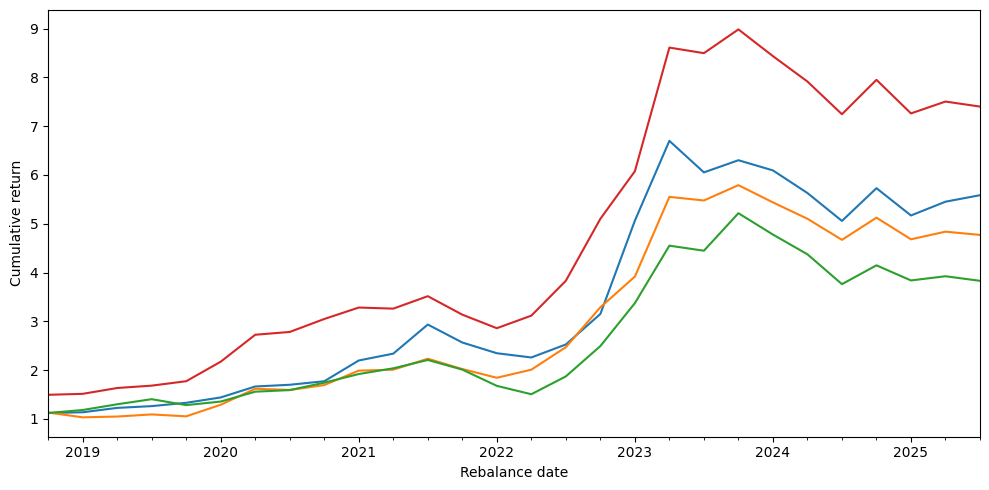

Saved: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/phase4_block3/block3_cumulative_returns.png
Selector model usage counts:
model_used           catboost_lags_regimes  elastic_net  kalman_tvp  lasso  \
strategy                                                                     
selector_composite                       6            6           8      3   
selector_rule_based                      6            0           0      0   

model_used           ols  patchtst_global  ridge  rolling_ols  
strategy                                                       
selector_composite     1                0      1            3  
selector_rule_based    0               17      5            0  


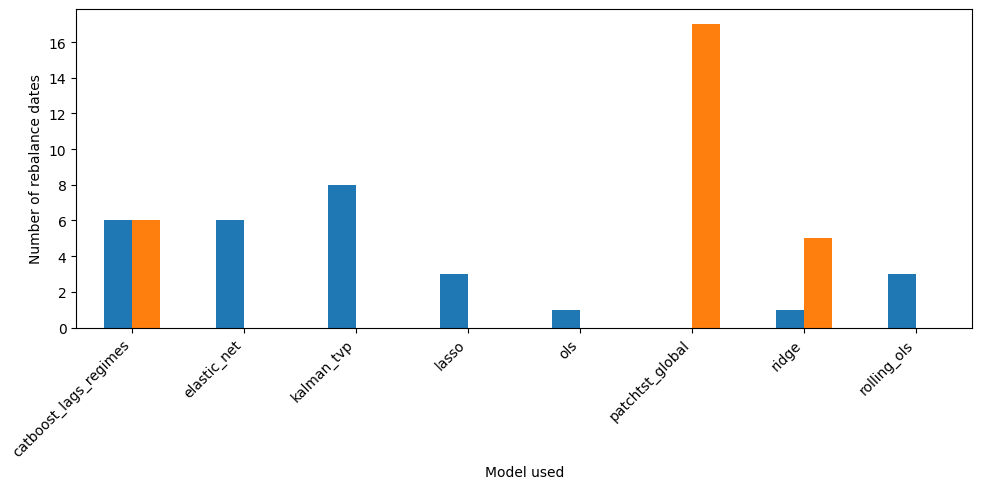

Saved selector model counts plot to: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/phase4_block3/block3_selector_model_counts.png


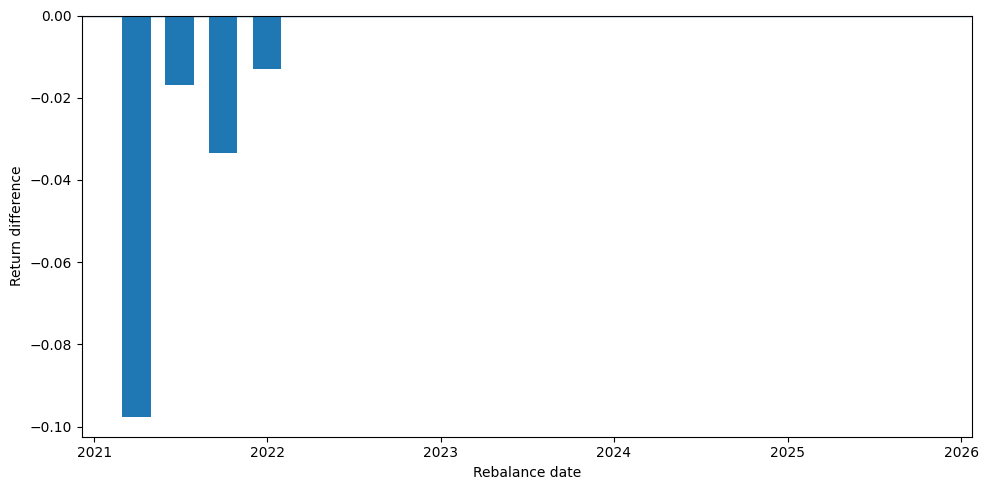

Saved: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/phase4_block3/block3_selector_minus_transformer_after2020.png


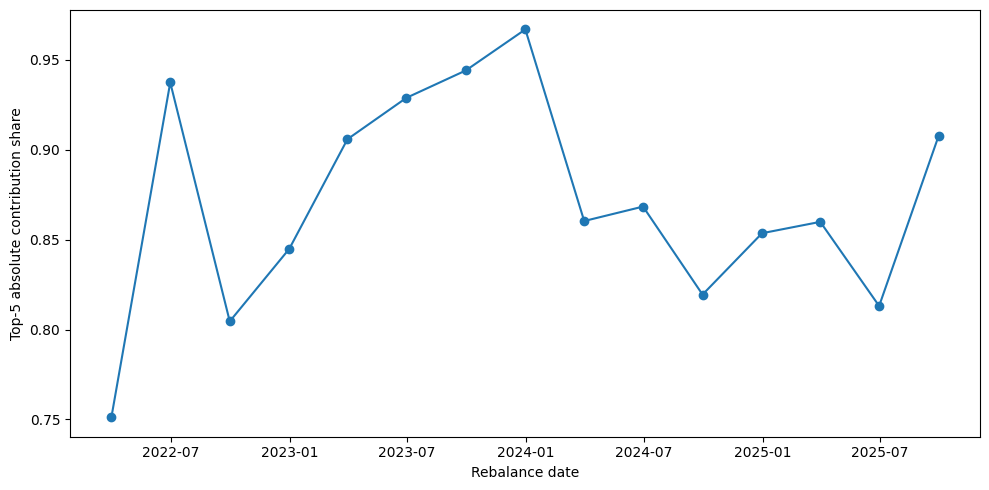

Saved: /content/drive/MyDrive/vega/data/model_comparison_advanced_results/phase4_block3/block3_patchtst_top5_contribution_share.png
Bootstrap CI overlap summary:


,metric,benchmark_strategy,median_diff_selector_minus_benchmark,ci_overlap_ratio_to_narrower,selector_materially_dominates,heavy_overlap
0,mean_return,always_linear,5.421951e-03,1.000000,False,True
1,mean_return,always_transformer,8.479150e-03,0.987629,False,True
2,annualized_return,always_linear,3.742655e-02,1.000000,False,True
3,annualized_return,always_transformer,4.017759e-02,0.979521,False,True
4,annualized_vol,always_linear,-3.915110e-02,1.000000,False,True
5,annualized_vol,always_transformer,-1.187856e-04,1.000000,False,True
6,sharpe,always_linear,2.186969e-01,0.944330,False,True
7,sharpe,always_transformer,1.267367e-01,0.956262,False,True
8,sortino,always_linear,4.235627e-02,1.000000,False,True
9,sortino,always_transformer,-1.071531e-01,0.985071,False,True


In [21]:
# =========================
# Phase 4 plots
# =========================

BLOCK3_DIR = OUTPUT_DIR / "phase4_block3"
BLOCK3_DIR.mkdir(parents=True, exist_ok=True)

if not portfolio_returns.empty:
    cum_returns = (
        portfolio_returns
        .sort_values(["strategy", "forecast_date"])
        .assign(cumulative=lambda x: x.groupby("strategy")["portfolio_return"].transform(lambda r: (1.0 + r).cumprod()))
        .pivot(index="forecast_date", columns="strategy", values="cumulative")
    )

    plt.figure(figsize=(10, 5))
    cum_returns.plot(ax=plt.gca())
    leg = plt.gca().get_legend()
    if leg is not None:
        leg.remove()
    plt.xlabel("Rebalance date")
    plt.ylabel("Cumulative return")
    plt.grid(False)
    plt.tight_layout()
    cumulative_path = BLOCK3_DIR / "block3_cumulative_returns.png"
    plt.savefig(cumulative_path, dpi=150)
    plt.show()
    print("Saved:", cumulative_path.resolve())

if not selector_log.empty:
    selector_counts = (
        selector_log.loc[
            selector_log["strategy"].isin(["selector_rule_based", "selector_composite"])
        ]
        .groupby(["strategy", "model_used"])
        .size()
        .unstack(fill_value=0)
    )

    print("Selector model usage counts:")
    print(selector_counts)

    if not selector_counts.empty:
        plt.figure(figsize=(10, 5))

        selector_counts.T.plot(kind="bar", ax=plt.gca())

        plt.xlabel("Model used")
        plt.ylabel("Number of rebalance dates")
        plt.xticks(rotation=45, ha="right")
        leg = plt.gca().get_legend()
        if leg is not None:
            leg.remove()
        plt.tight_layout()

        selector_counts_path = BLOCK3_DIR / "block3_selector_model_counts.png"
        plt.savefig(selector_counts_path, dpi=200, bbox_inches="tight")
        plt.show()

        print(f"Saved selector model counts plot to: {selector_counts_path}")
    else:
        print("No selector model counts to plot.")
else:
    print("selector_log is empty.")

# =========================
# Additional reviewer plots
# =========================

if "selector_vs_transformer_after2020" in globals() and not selector_vs_transformer_after2020.empty:
    diff_plot = selector_vs_transformer_after2020.copy()
    diff_plot["forecast_date"] = pd.to_datetime(diff_plot["forecast_date"])

    plt.figure(figsize=(10, 5))
    plt.bar(
        diff_plot["forecast_date"],
        diff_plot["return_diff_selector_minus_transformer"],
        width=60,
    )
    plt.axhline(0.0, linewidth=1)

    plt.xlabel("Rebalance date")
    plt.ylabel("Return difference")
    plt.grid(False)
    plt.tight_layout()

    path = BLOCK3_DIR / "block3_selector_minus_transformer_after2020.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

if "patchtst_selected_concentration" in globals() and not patchtst_selected_concentration.empty:
    conc_plot = patchtst_selected_concentration.copy()
    conc_plot["forecast_date"] = pd.to_datetime(conc_plot["forecast_date"])

    plt.figure(figsize=(10, 5))
    plt.plot(
        conc_plot["forecast_date"],
        conc_plot["top5_abs_contribution_share"],
        marker="o",
    )

    plt.xlabel("Rebalance date")
    plt.ylabel("Top-5 absolute contribution share")
    plt.grid(False)
    plt.tight_layout()

    path = BLOCK3_DIR / "block3_patchtst_top5_contribution_share.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    print("Saved:", path)

if "bootstrap_ci_overlap" in globals() and not bootstrap_ci_overlap.empty:
    print("Bootstrap CI overlap summary:")
    display(
        bootstrap_ci_overlap[
            [
                "metric",
                "benchmark_strategy",
                "median_diff_selector_minus_benchmark",
                "ci_overlap_ratio_to_narrower",
                "selector_materially_dominates",
                "heavy_overlap",
            ]
        ]
    )
